In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns

import cv2
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
import hashlib


from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
from google.colab import userdata
import kagglehub

os.environ['KAGGLE_USERNAME'] = 'viktoryamargaryan'
os.environ['KAGGLE_KEY'] = '81e38abe0ed4809aef50f07e572425fa'


In [ ]:
# 3. Ներբեռնում ենք ֆայլը
!kaggle competitions download -c cassava-leaf-disease-classification

# 4. Ապափաթեթավորում ենք cassava_data թղթապանակում
!unzip -q cassava-leaf-disease-classification.zip -d cassava_data

# 5. Ջնջում ենք zip-ը, որ տեղ ազատվի
!rm cassava-leaf-disease-classification.zip

100% 5.76G/5.76G [00:43<00:00, 143MB/s] 



In [ ]:
# 1. Նշում ենք Drive-ի ճիշտ հասցեն
import kagglehub
import os
DATASET_PATH = '/content/cassava_data'

# 2. Տեսնում ենք նկարների լեյբլները (CSV-ն)
df = pd.read_csv(f'{DATASET_PATH}/train.csv')
print('Տվյալների քանակը:', len(df))
print(df.head())

# 3. Տեսնում ենք հիվանդությունների անվանումները
with open(f'{DATASET_PATH}/label_num_to_disease_map.json') as f:
  mapping = json.load(f)
print('\nՀիվանդությունների ցանկը:', mapping)

Տվյալների քանակը: 21397
         image_id  label
0  1000015157.jpg      0
1  1000201771.jpg      3
2   100042118.jpg      1
3  1000723321.jpg      1
4  1000812911.jpg      3

Հիվանդությունների ցանկը: {'0': 'Cassava Bacterial Blight (CBB)', '1': 'Cassava Brown Streak Disease (CBSD)', '2': 'Cassava Green Mottle (CGM)', '3': 'Cassava Mosaic Disease (CMD)', '4': 'Healthy'}


In [ ]:
df

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3
...,...,...
21392,999068805.jpg,3
21393,999329392.jpg,3
21394,999474432.jpg,1
21395,999616605.jpg,4


##Starting EDA

In [ ]:

print(len(df))
print(df.head())


21397
         image_id  label
0  1000015157.jpg      0
1  1000201771.jpg      3
2   100042118.jpg      1
3  1000723321.jpg      1
4  1000812911.jpg      3


In [ ]:

print("=== 1.  ԸՆԴՀԱՆՈՒՐ ՏԵՂԵԿՈՒԹՅՈՒՆ ===")
df.info()

=== 1.  ԸՆԴՀԱՆՈՒՐ ՏԵՂԵԿՈՒԹՅՈՒՆ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21397 entries, 0 to 21396
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   image_id  21397 non-null  object
 1   label     21397 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 334.5+ KB


In [ ]:

print("\n=== 2. MISSING VALUES  ===")
missing_data = df.isnull().sum()
print(missing_data)


=== 2. MISSING VALUES  ===
image_id    0
label       0
dtype: int64


0: Cassava Bacterial Blight (CBB)

1: Cassava Brown Streak Disease (CBSD)

2: Cassava Green Mottle (CGM)

3: Cassava Mosaic Disease (CMD)

4: Healthy

##Unique values

In [ ]:

unique_labels = sorted(df['label'].unique())
print("Unique labels in dataset:", unique_labels)

Unique labels in dataset: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


Unique classes-ի քանակը

In [ ]:

num_classes = df['label'].nunique()
print("Number of unique classes:", num_classes)

Number of unique classes: 5


Գտնում ենք բոլոր այն արժեքները, որոնք 0-4 range-ից դուրս են

In [ ]:

expected_set = {0, 1, 2, 3, 4}
invalid_rows = df[~df['label'].isin(expected_set)]
print(f"Invalid label rows count: {len(invalid_rows)}")

Invalid label rows count: 0


In [ ]:

df_viz = df.copy()

label_map = {
    0: "Cassava Bacterial Blight (CBB)",
    1: "Cassava Brown Streak Disease (CBSD)",
    2: "Cassava Green Mottle (CGM)",
    3: "Cassava Mosaic Disease (CMD)",
    4: "Healthy"
}

#  Ավելացնում ենք հիվանդության անվան սյունյակը copy-ի մեջ
df_viz['disease_name'] = df_viz['label'].map(label_map)

df_viz

,image_id,label,disease_name
0,1000015157.jpg,0,Cassava Bacterial Blight (CBB)
1,1000201771.jpg,3,Cassava Mosaic Disease (CMD)
2,100042118.jpg,1,Cassava Brown Streak Disease (CBSD)
3,1000723321.jpg,1,Cassava Brown Streak Disease (CBSD)
4,1000812911.jpg,3,Cassava Mosaic Disease (CMD)
...,...,...,...
21392,999068805.jpg,3,Cassava Mosaic Disease (CMD)
21393,999329392.jpg,3,Cassava Mosaic Disease (CMD)
21394,999474432.jpg,1,Cassava Brown Streak Disease (CBSD)
21395,999616605.jpg,4,Healthy


Յուրքանչյուր տեսակից քանի նկար կա

In [ ]:

class_counts = df_viz['disease_name'].value_counts()
print(class_counts)

disease_name
Cassava Mosaic Disease (CMD)           13158
Healthy                                 2577
Cassava Green Mottle (CGM)              2386
Cassava Brown Streak Disease (CBSD)     2189
Cassava Bacterial Blight (CBB)          1087
Name: count, dtype: int64


Նույնը տոկոսային հարաբերությամբ

In [ ]:

class_percentages = (df_viz['disease_name'].value_counts(normalize=True).sort_index() * 100).round(2)

print("--- Class Percentages ---")
print(class_percentages)

--- Class Percentages ---
disease_name
Cassava Bacterial Blight (CBB)          5.08
Cassava Brown Streak Disease (CBSD)    10.23
Cassava Green Mottle (CGM)             11.15
Cassava Mosaic Disease (CMD)           61.49
Healthy                                12.04
Name: proportion, dtype: float64


In [ ]:

import os

# Ստեղծում ենք EDA գրաֆիկների թղթապանակը Drive-ում
plots_dir = '/content/drive/MyDrive/Cassava_Project/plots'
os.makedirs(plots_dir, exist_ok=True)

Կառուցենք  Bar Chart

/tmp/ipykernel_2308/284558731.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


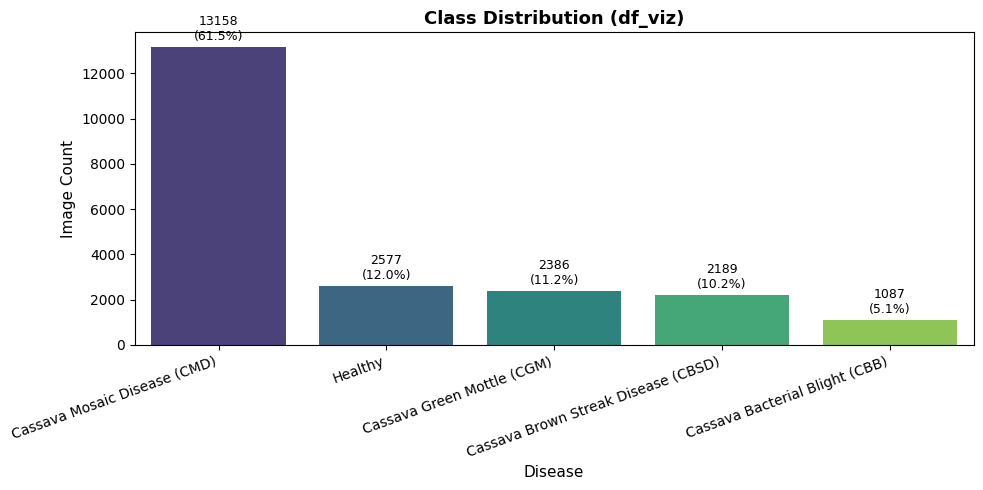

In [ ]:

chart_data = df_viz['disease_name'].value_counts().reset_index()
chart_data.columns = ['disease_name', 'count']
chart_data['percentage'] = (chart_data['count'] / len(df_viz) * 100).round(2)

# 2. Կառուցում ենք գրաֆիկը
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=chart_data,
    x='disease_name',
    y='count',
    palette='viridis'
)

plt.title('Class Distribution (df_viz)', fontsize=13, fontweight='bold')
plt.xlabel('Disease', fontsize=11)
plt.ylabel('Image Count', fontsize=11)
plt.xticks(rotation=20, ha='right')

# 3. Ավելացնում ենք քանակն ու տոկոսը սյուների վրա
for p in ax.patches:
    height = int(p.get_height())
    pct = (height / len(df_viz) * 100)
    ax.annotate(
        f'{height}\n({pct:.1f}%)',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        fontsize=9, xytext=(0, 3),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

In [ ]:

#Գտնենք ամենամեծ class-ը
max_class_name = class_counts.idxmax()
max_class_count = class_counts.max()
max_class_pct = (max_class_count / len(df_viz)) * 100

# 2. Գտնենք ամենափոքր class-ը
min_class_name = class_counts.idxmin()
min_class_count = class_counts.min()
min_class_pct = (min_class_count / len(df_viz)) * 100

# 3. Համեմատենք class-երի չափերը (Imbalance Ratio)
imbalance_ratio = max_class_count / min_class_count

print(f" Ամենամեծ class:  {max_class_name} -> {max_class_count:,} պատկեր ({max_class_pct:.2f}%)")
print(f" Ամենափոքր class: {min_class_name} -> {min_class_count:,} պատկեր ({min_class_pct:.2f}%)")
print(f" Imbalance ratio (Max / Min): {imbalance_ratio:.2f}x")

 Ամենամեծ class:  Cassava Mosaic Disease (CMD) -> 13,158 պատկեր (61.49%)
 Ամենափոքր class: Cassava Bacterial Blight (CBB) -> 1,087 պատկեր (5.08%)
 Imbalance ratio (Max / Min): 12.10x


Խիստ անհամաչափություն (Class Imbalance):
Ամենամեծ դասը (CMD) ~12.1 անգամ ավելի մեծ է, քան ամենափոքր դասը (CBB)։

Dominant Class:
Ամբողջ դատասեթի պատկերների ավելի քան 61%-ը պատկանում է ընդամենը 1 դասի (CMD)։

Եթե մոդելը սովորական ձևով թրեյն անենք, այն կարող է բիասավորվել (biased) դեպի CMD-ն և վատ ճանաչել CBB-ն կամ մյուս հազվադեպ դասերը։ Սա նշանակում է, որ հետագայում պետք կգա․

Stratified K-Fold (որպեսզի ամեն fold-ում դասերի հարաբերակցությունը պահպանվի)

Weighted Loss Function կամ Class Weights

Հատուկ Augmentation տեխնիկաներ փոքր դասերի համա

**Դիտարկենք յուրաքանչյուր class-ից sample-ներ **

In [ ]:

import os

# Define Drive path
BASE_DIR = '/content/cassava_data'

print("Ընթացիկ թղթապանակի ֆայլերը:")
print(os.listdir(BASE_DIR))

if os.path.exists(f'{BASE_DIR}/train_images'):
  IMAGES_DIR = f'{BASE_DIR}/train_images'
else:
  IMAGES_DIR = BASE_DIR

print(f"Օգտագործվող path: {IMAGES_DIR}")

Ընթացիկ թղթապանակի ֆայլերը:
['test_tfrecords', 'sample_submission.csv', 'train_images', 'test_images', 'train.csv', 'label_num_to_disease_map.json', 'train_tfrecords']
Օգտագործվող path: /content/cassava_data/train_images


In [ ]:

if not os.path.exists(IMAGES_DIR):
    print(f" Թղթապանակը չի գտնվել: {IMAGES_DIR}")
    print("Խնդրում եմ ստուգել ճիշտ path-ը os.listdir()-ով:")


samples_per_class = 3
fig, axes = plt.subplots(5, samples_per_class, figsize=(15, 15))

for label in range(5):
    class_df = df_viz[df_viz['label'] == label].sample(samples_per_class)
    disease_title = class_df['disease_name'].iloc[0]

    for i, (_, row) in enumerate(class_df.iterrows()):
        img_path = os.path.join(IMAGES_DIR, row['image_id'])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax = axes[label, i]
        ax.imshow(img)
        ax.axis('off')
        if i == 1:
            ax.set_title(f"Class {label}: {disease_title}", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

CBB (Class 0): Տերևների վրա առկա են մուգ շագանակագույն, չորացած անկյունաձև բծեր (water-soaked lesions) և եզրերի այրված/չորացած տեսք։

CBSD (Class 1): Դեղնավուն և շագանակագույն նախշերը տարածված են հիմնականում տերևի ջղերի (veins) երկայնքով։

CGM (Class 2): Տերևի մակերեսին նկատվում են մանր, սպեկտրալ դեղնավուն/բաց-կանաչավուն կետեր ու բծեր (mottling)։

CMD (Class 3): Տերևները խիստ ծռմռված են, կնճռոտված և ասիմետրիկ՝ դեղնականաչավուն խճանկարային pattern-ով։

Healthy (Class 4): Տերևները հիմնականում հարթ են և առողջ կանաչ, սակայն առկա է Label Noise (որոշ նկարներում տեսանելի են հիվանդության բծեր կամ արտաքին վնասվածքներ)։

Նմանություններ և Ռիսկեր: CBB-ն և CBSD-ն տեսողականորեն բավականին նման են (շագանակագույն բծեր/դեղնում), ինչը կարող է առաջացնել misclassification: Background-ները և լուսավորվածությունը խիստ փոփոխական են։

Վերջին շարքի աջ կողմի երրորդ նկարում ակնհայտ երևում են չորացած, շագանակագույն բծեր, որոնք CBB-ի կամ CBSD-ի ախտանիշ են, բայց դատասեթում այն նշված է որպես Class 4 (Healthy)։

Cassava Leaf Disease դատասեթի ամենահայտնի խնդիրներից մեկն է՝ Label Noise (սխալ/աղմկոտ լեյբլավորում)։

Մոդելը չի կարող հասնել 100% Accuracy-ի․ Քանի որ ground truth (ճիշտ պատասխան համարվող) տվյալների մեջ սխալներ կան, նույնիսկ կատարյալ մոդելը Kaggle-ում ~89-90% accuracy-ից վերև դժվար է բարձրանում։

Label Smoothing Loss․ Սովորական Cross-Entropy Loss-ի փոխարեն շատ օգտակար է օգտագործել Label Smoothing (օրինակ՝ smoothing=0.1)։ Սա թույլ է տալիս, որ մոդելը 100% վստահությամբ չհավատա սխալ լեյբլին և պատժվի ավելի քիչ, երբ տվյալներում աղմուկ (noise) կա։

Symmetric Cross Entropy (SCE) կամ Bi-Tempered Loss․ Այս հատուկ Loss function-ները նախագծված են հենց այսպիսի աղմկոտ (noisy) դատասեթերի դեմ պայքարելու համար։

Background-ների տարբերությունը

Խիստ բազմազան են․ Նկարներում երևում են հող, այլ ոչ հիվանդ/առողջ բույսեր, չորացած ցողուններ, իսկ որոշ sample-ներում նաև մարդու ձեռքեր կամ տերևը պահող մատներ։

Մոդելի ռիսկ․ Մոդելը կարող է պատահաբար սովորել background-ի դետալները (օրինակ՝ հողի գույնը) տերևի հիվանդության հետ կապելու փոխարեն։

Լուծում․ Պարտադիր է Random Resized Crop և Zoom augmentation-ների օգտագործումը, որպեսզի մոդելի ուշադրությունը կենտրոնանա միայն տերևի վրա։

Lighting-ի (լուսավորվածության) տարբերությունը

Խիստ փոփոխական է․ Կան պայծառ, ուղիղ արևի տակ արված նկարներ (որոնք տերևի վրա սպիտակ փայլեր/glare են առաջացնում), ինչպես նաև ստվերում կամ մռայլ եղանակին նկարված մութ կադրեր։

Մոդելի ռիսկ․ Արևի փայլերը մոդելը կարող է սխալմամբ ընդունել որպես CGM-ի դեղնավուն բծեր, իսկ մութ ստվերները՝ CBB-ի չորացած հատվածներ։

Լուծում․ ColorJitter, Brightness, and Contrast augmentation-ների կիրառումը թրեյնինգի ընթացքում։

In [ ]:

image_shapes = []
formats = set()

# Անցնում ենք բոլոր նկարների վրայով և հավաքում տվյալները
sample_df = df_viz.sample(1000, random_state=42)
for img_name in sample_df['image_id']:
    img_path = os.path.join(IMAGES_DIR, img_name)
    with Image.open(img_path) as img:
        width, height = img.size
        # Get channels (e.g. RGB -> 3)
        channels = len(img.getbands())
        formats.add(img.format)
        image_shapes.append((width, height, channels))

# Դարձնում ենք DataFrame վերլուծության համար
shapes_df = pd.DataFrame(image_shapes, columns=['width', 'height', 'channels'])

print("--- Image Dimensions & Channels ---")
print(shapes_df.describe())
print(f"\nUnique Formats: {formats}")
print(f"Unique Channels: {shapes_df['channels'].unique()}")

--- Image Dimensions & Channels ---
        width  height  channels
count  1000.0  1000.0    1000.0
mean    800.0   600.0       3.0
std       0.0     0.0       0.0
min     800.0   600.0       3.0
25%     800.0   600.0       3.0
50%     800.0   600.0       3.0
75%     800.0   600.0       3.0
max     800.0   600.0       3.0

Unique Formats: {'JPEG'}
Unique Channels: [3]


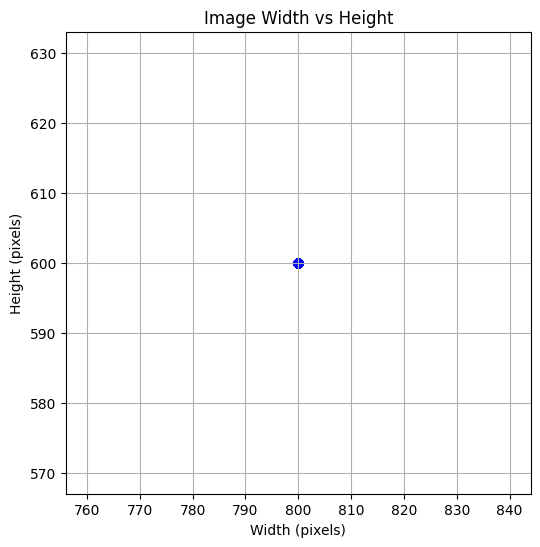

In [ ]:

widths, heights = [], []

# Օգտագործում ենք ավելի վաղ ստացված shapes_df-ը կամ նորից կարդում sample
sample_df = df_viz.sample(1000, random_state=42)
for img_name in sample_df['image_id']:
    img_path = os.path.join(IMAGES_DIR, img_name)
    img = cv2.imread(img_path)
    if img is not None:
        heights.append(img.shape[0])
        widths.append(img.shape[1])

plt.figure(figsize=(6, 6))
plt.scatter(widths, heights, alpha=0.5, c='blue')
plt.title("Image Width vs Height")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.grid(True)
plt.show()

Սա վերջնականապես վստահեցնում է, որ preprocessing-ի ժամանակ բարդ aspect-ratio-preserving resize-ների (օրինակ՝ եզրերին սև գոտիներ / padding ավելացնելուն) կարիք չկա։ Կարող ենք ուղիղ resize անել քառակուսի (օրինակ՝ 256x256)։

Արդյունքները

Width & Height: Բոլոր պատկերները standard 800 x 600 resolution ունեն (800px width, 600px height)։

Minimum Dimensions: 800 x 600

Maximum Dimensions: 800 x 600

Channels: 3 (RGB color channels)

Image Format: JPEG (.jpg)

Key Takeaway Modeling-ի համար.
Դատասեթը չափսերի առումով լիովին uniform (միատարր) է՝ չկան տարբեր չափսերի կամ corrupted format-ով նկարներ։ Այնուամենայնիվ, թրեյնինգի ժամանակ բոլորը resize կանենք (օրինակ՝ 224x224, 384x384 կամ 512x512), որպեսզի GPU-ն ավելի արագ մշակի։

In [ ]:

# 1. Missing / Invalid labels & Duplicate rows
missing_labels = df['label'].isnull().sum()
invalid_labels = (~df['label'].isin(range(5))).sum()
duplicate_rows = df.duplicated().sum()

# 2. Missing files, Corrupted images, Formats & Image Hashing for Duplicates
missing_files = 0
corrupted_images = 0
unexpected_formats = []
image_hashes = set()
duplicate_images_count = 0

for img_name in df['image_id']:
    img_path = os.path.join(IMAGES_DIR, img_name)

    # Check if file exists
    if not os.path.exists(img_path):
        missing_files += 1
        continue

    try:
        with Image.open(img_path) as img:
            img.verify() # Corrupted image check

        # Format check
        if not img_name.lower().endswith(('.jpg', '.jpeg')):
            unexpected_formats.append(img_name)

        # Duplicate images check via MD5 Hash
        with open(img_path, 'rb') as f:
            file_hash = hashlib.md5(f.read()).hexdigest()
            if file_hash in image_hashes:
                duplicate_images_count += 1
            else:
                image_hashes.add(file_hash)

    except Exception:
        corrupted_images += 1

print("=== Data Quality & Integrity Report ===")
print(f" Missing labels: {missing_labels}")
print(f" Invalid labels (not 0-4): {invalid_labels}")
print(f" Duplicate DataFrame rows: {duplicate_rows}")
print(f" Missing image files: {missing_files}")
print(f" Corrupted images: {corrupted_images}")
print(f" Duplicate images (exact file match): {duplicate_images_count}")
print(f" Unexpected file formats: {len(unexpected_formats)}")

=== Data Quality & Integrity Report ===
 Missing labels: 0
 Invalid labels (not 0-4): 0
 Duplicate DataFrame rows: 0
 Missing image files: 0
 Corrupted images: 0
 Duplicate images (exact file match): 0
 Unexpected file formats: 0


Դատասեթը տեխնիկական առումով շատ մաքուր է (ֆայլերը ամբողջական են, չկան corrupted կամ չբացվող նկարներ): Միակ հիմնական խնդիրները, որոնց դեմ պետք է պայքարենք մոդելավորման ժամանակ, նախորդ քայլերում գտած Class Imbalance-ը և Label Noise-ն են

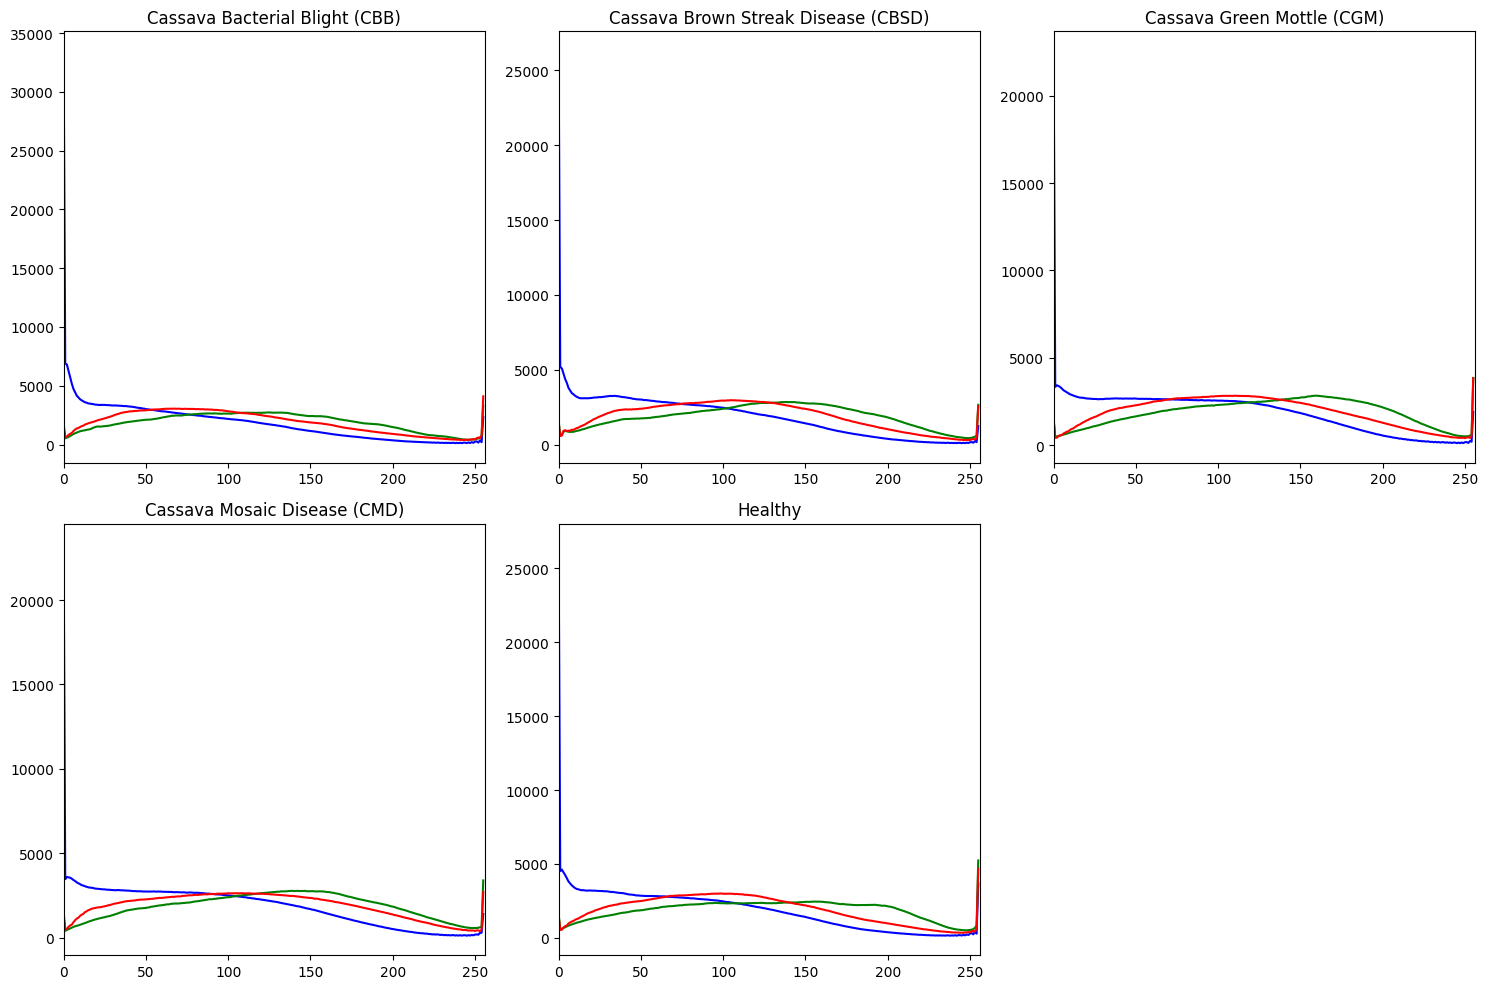

In [ ]:

colors = ('b', 'g', 'r')
plt.figure(figsize=(15, 10))

for label in range(5):
    class_sample = df_viz[df_viz['label'] == label].sample(100, random_state=42)
    disease_name = class_sample['disease_name'].iloc[0]

    mean_hist = {c: np.zeros((256, 1)) for c in colors}

    for img_name in class_sample['image_id']:
        img_path = os.path.join(IMAGES_DIR, img_name)
        img = cv2.imread(img_path)
        for i, col in enumerate(colors):
            hist = cv2.calcHist([img], [i], None, [256], [0, 256])
            mean_hist[col] += hist / 100

    plt.subplot(2, 3, label + 1)
    for col in colors:
        plt.plot(mean_hist[col], color=col)
    plt.title(disease_name)
    plt.xlim([0, 256])

plt.tight_layout()
plt.savefig(
    f'{plots_dir}/color_histograms_per_class.png', dpi=300, bbox_inches='tight'
)
plt.show()

Blue Channel Spike (մուգ կապույտ պիկը 0-ի վրա)․
Բոլոր դասերի մոտ 0-ական ինտենսիվության վրա կա շատ բարձր Blue (B) պիկ։ Սա ցույց է տալիս, որ նկարներում Blue channel-ի ցածր արժեքները (գրեթե 0) շատ են, ինչը բնական է կանաչ տերևների և մուգ/ստվերոտ ֆոնի համար (RGB համակարգում կանաչն ու դեղինը ունեն շատ ցածր Blue ինտենսիվություն)։

Green vs Red channels (Կանաչի և Կարմիրի հարաբերակցությունը)․

Healthy (Առողջ)․ Կանաչ (Green) կորը 150-200 տիրույթում ակնհայտ բարձր է Կարմիրից (Red)։ Սա մաթեմատիկորեն հաստատում է առողջ, հագեցած կանաչ տերևների առկայությունը։

CBB & CBSD (Հիվանդություններ)․ Կանաչի և Կարմիրի կորերը շատ մոտ են իրար, իսկ որոշ հատվածներում Կարմիրը բարձրանում է։ Սա չորացած, շագանակագույն ու դեղնած հատվածների (Green-ի նվազման և Red-ի բարձրացման) ուղղակի հետևանքն է։

CGM & CMD․ Ունեն բավականին հավասարաչափ բաշխում, քանի որ տերևների վրա կան թե՛ կանաչ, թե՛ դեղնավուն (Mosaic/Mottle) հատվածներ։

Color Augmentations-ի սահմանափակում․
Hue (գույնի երանգ) augmentation-ը պետք է կիրառել շատ զգույշ կամ շատ փոքր range-ով (օրինակ՝ hue_shift_limit=5): Եթե գույները շատ փոխենք, կանաչ տերևը կարող է դառնալ դեղնավուն, և մոդելը Healthy-ն կշփոթի CGM-ի կամ CBSD-ի հետ։

Brightness / Contrast Augmentation-ի անհրաժեշտություն․
Քանի որ 0-250 տիրույթում ինտենսիվությունները լայն տարածված են (լուսավորության խիստ տատանումների պատճառով), Brightness/Contrast փոփոխությունները կօգնեն մոդելին անկախ լինել լուսավորությունից։

Normalization Constants (ImageNet standards)․
Թրեյնինգի ժամանակ ImageNet-ի standard mean/std-ով normalize անելը (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) լիովին արդարացված է, քանի որ RGB ալիքների բաշխվածությունը բնական լուսանկարների standard կառուցվածք ունի։

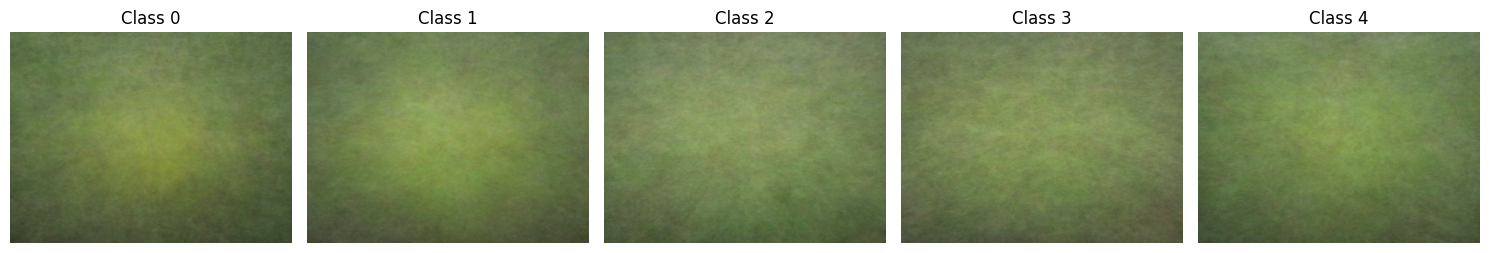

In [ ]:

plt.figure(figsize=(15, 6))

for label in range(5):
    class_sample = df_viz[df_viz['label'] == label].sample(100, random_state=42)
    disease_name = class_sample['disease_name'].iloc[0]

    # Նախապես ստեղծում ենք զրոյական մատրիցա
    mean_img = np.zeros((600, 800, 3), dtype=np.float32)

    for img_name in class_sample['image_id']:
        img_path = os.path.join(IMAGES_DIR, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mean_img += img / 100

    mean_img = np.uint8(mean_img)

    plt.subplot(1, 5, label + 1)
    plt.imshow(mean_img)
    plt.title(f"Class {label}")
    plt.axis('off')

plt.tight_layout()
plt.savefig(
    f'{plots_dir}/mean_images.png', dpi=300, bbox_inches='tight'
)
plt.show()

Կենտրոնացված լուսավորություն/դեղնություն (Class 0 & Class 1)՝
Class 0-ի (CBB) և Class 1-ի (CBSD) միջինացված պատկերներում կենտրոնում ակնհայտ երևում է ավելի վառ, դեղնավուն/բաց-կանաչ կլորավուն տիրույթ։ Սա հաստատում է, որ այս հիվանդությունների դեպքում ֆոտոգրաֆները/ֆերմերները նկարելիս կադրի կենտրոնը ուղղել են հենց վնասված, դեղնած տերևի վրա։

Լղոզված և միատարր ֆոն (Class 2, 3, 4)՝
Class 2-ի, 3-ի և 4-ի (Healthy) մոտ պատկերը շատ ավելի միատարր կանաչ-մոխրագույն է։ Սա նշանակում է, որ այս դասերում տերևների դիրքավորումն ու չափսերը կադրում ավելի պատահական են բաշխված։

Ոչ մի class-ի մոտ չկա հստակ «տերևի տեսք» (edges): Սա ցույց է տալիս, որ դատասեթում տերևների անկյունները (orientations), մասշտաբները (scales) և background-ները խիստ բազմազան են։

Spatial/Position Invariance-ի կարիք՝
Քանի որ հիվանդությունները միայն կենտրոնում չեն, մոդելը չպետք է «կախվածություն» ձեռք բերի նկարի կենտրոնական հատվածից։

Անհրաժեշտ Augmentation-ներ՝

Random Horizontal & Vertical Flips: Օգնում է, որ մոդելը սովորի pattern-ները անկախ տերևի ուղղությունից։

ShiftScaleRotate / Random Crop: Ստիպում է մոդելին գտնել ախտանիշները, նույնիսկ եթե տերևը կադրի անկյունում է կամ խոշոր պլանով (zoom):

## **Preprocessing**

In [ ]:

# 1. Train/Validation Split (80% Train, 20% Val)
# Stratified split-ը պահպանում է class-երի տոկոսային հարաբերակցությունը
train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['label']
)

# Drive-ում CSV-ների պահպանում
SPLIT_SAVE_DIR = '/content/drive/MyDrive/Cassava_Project'
os.makedirs(SPLIT_SAVE_DIR, exist_ok=True)

train_df.to_csv(f'{SPLIT_SAVE_DIR}/train_split.csv', index=False)
val_df.to_csv(f'{SPLIT_SAVE_DIR}/val_split.csv', index=False)

print(" Train և Validation CSV-ները պահպանվեցին Drive-ում:")

# 2. Ստուգել set-երի չափերը
print(f"Training set size: {len(train_df)} images ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation set size: {len(val_df)} images ({len(val_df)/len(df)*100:.1f}%)")




# 3. Համեմատել Class Distribution-ը երկու set-երում (Տոկոսային)
train_dist = train_df['label'].value_counts(normalize=True).sort_index() * 100
val_dist = val_df['label'].value_counts(normalize=True).sort_index() * 100

dist_df = pd.DataFrame({
    'Train (%)': train_dist,
    'Validation (%)': val_dist
})
print("\n--- Class Distribution Comparison ---")
print(dist_df.round(2))

# 4. Համոզվել, որ validation images-ը training-ում չեն հայտնվել (Data Leakage Check)
intersection = set(train_df['image_id']).intersection(set(val_df['image_id']))
print(f"\nOverlap between Train and Validation: {len(intersection)} images")
assert len(intersection) == 0, "ERROR: Data leakage detected!"

 Train և Validation CSV-ները պահպանվեցին Drive-ում:
Training set size: 17117 images (80.0%)
Validation set size: 4280 images (20.0%)

--- Class Distribution Comparison ---
       Train (%)  Validation (%)
label                           
0           5.08            5.07
1          10.23           10.23
2          11.15           11.14
3          61.49           61.50
4          12.04           12.06

Overlap between Train and Validation: 0 images


In [ ]:

import os
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# 1. Transform-ներ (Ստանդարտ torchvision)
def get_pytorch_transforms(img_size=384):
    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std = [0.229, 0.224, 0.225]

    train_transform = T.Compose([
        T.RandomResizedCrop(size=(img_size, img_size), scale=(0.8, 1.0)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomVerticalFlip(p=0.5),
        T.ToTensor(),
        T.Normalize(mean=imagenet_mean, std=imagenet_std)
    ])

    valid_transform = T.Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize(mean=imagenet_mean, std=imagenet_std)
    ])

    return train_transform, valid_transform


# 2. Dataset դասը
class CassavaPyTorchDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iat[idx, self.df.columns.get_loc('image_id')]
        label = self.df.iat[idx, self.df.columns.get_loc('label')]
        img_path = os.path.join(self.img_dir, img_name)

        with Image.open(img_path) as img:
            image = img.convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)




#Augmentation-ի Ստուգման Կոդ (Visual Verification)

In [ ]:

def get_visual_augmentation_pipeline(img_size=384):
    return T.Compose([
        T.RandomResizedCrop(size=(img_size, img_size), scale=(0.8, 1.0)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomVerticalFlip(p=0.5),
        T.RandomRotation(degrees=15),
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1)
    ])


def check_augmentation_quality(df, img_dir, num_samples=5, augmentations_per_img=3):
    aug_pipeline = get_visual_augmentation_pipeline()

    # Ընտրում ենք տարբեր դասերի 3 նկար
    sample_rows = df.drop_duplicates(subset=['label']).head(num_samples)

    fig, axes = plt.subplots(num_samples, augmentations_per_img + 1, figsize=(16, 4 * num_samples))

    for row_idx, (_, row) in enumerate(sample_rows.iterrows()):
        img_path = os.path.join(img_dir, row['image_id'])
        label = row['label']
        orig_img = Image.open(img_path).convert("RGB")

        # Original Image
        axes[row_idx, 0].imshow(orig_img.resize((384, 384)))
        axes[row_idx, 0].set_title(f"ORIGINAL (Label: {label})", color='green', fontweight='bold')
        axes[row_idx, 0].axis('off')

        # Augmented Variants
        for aug_idx in range(1, augmentations_per_img + 1):
            aug_img = aug_pipeline(orig_img)
            axes[row_idx, aug_idx].imshow(aug_img)
            axes[row_idx, aug_idx].set_title(f"Augmented #{aug_idx}")
            axes[row_idx, aug_idx].axis('off')

    plt.tight_layout()
    plt.show()

# 3. Աշխատացնել վիզուալիզացիան
check_augmentation_quality(train_df, img_dir=IMAGES_DIR)

Output hidden; open in https://colab.research.google.com to view.

Preprocessing & Data Pipeline Specification1. Data Ingestion & Lazy Loading Strategy

Image Loading Mechanics:Պատկերները ֆայլային համակարգից (Disk/SSD) կարդացվում են ըստ պահանջի (Lazy Loading)՝ կանխելու RAM-ի գերբեռնումը։ Օգտագործվում է PIL.Image.open(), որից անմիջապես հետո կատարվում է .convert("RGB")՝ երաշխավորելով 3-ալիքանի RGB ձևաչափը (արտահոսքերը կամ RGBA/Grayscale անոմալիաները բացառելու համար)։


Leak-Free Dataset Design: CassavaPyTorchDataset դասը չի փոփոխում սկզբնական DataFrame-ը։ Ֆայլերի հասցեները կառուցվում են դինամիկ կերպով (os.path.join(img_dir, image_id)), ինչը ապահովում է ճկունություն միջավայրերի միջև (Colab, Local GPU, Kaggle):


2. Spatial Transformations & Resolution

Target Resolution (384x384): Սկզբնական 800x600 չափսից իջեցումը 384x384-ի օպտիմալ բալանս է GPU VRAM-ի ծախսի և տերևների մանր ախտանիշների (նեկրոտիկ բծեր, ջղերի դեղնացում) պահպանման միջև։

Training Resizing Strategy (RandomResizedCrop):size=(384, 384), scale=(0.8, 1.0)Պատահականորեն կտրում է պատկերի 80-100%-ը և մասշտաբավորում։ Սա կանխում է մոդելի կապվածությունը ախտանիշների կոնկրետ չափսի կամ դիրքի հետ (Scale Invariance):

Validation Resizing Strategy (Resize):size=(384, 384)Ուղղակի Resize՝ առանց պատահական կտրումների։ Սա ապահովում է Validation Metric-ների դետերմինիստիկ, կրկնելի և ճշգրիտ գնահատումը։


3. Data Augmentations (Regularization)

Overfitting-ից խուսափելու և մոդելի generalizability-ն բարձրացնելու համար Train pipeline-ում կիրառվում են հետևյալ սպատիալ ձևափոխությունները՝

RandomHorizontalFlip(p=0.5) — 50% հավանականությամբ հորիզոնական արտացոլում։

RandomVerticalFlip(p=0.5) — 50% հավանականությամբ ուղղահայաց արտացոլում։

4. Tensor Conversion & Intensity Normalization


PILToTensor(): PIL Image պատկերը փոխարկում է PyTorch Tensor-ի (uint8), միաժամանակ փոխելով չափսերի կարգը՝ [Height, Width, Channels] $\rightarrow$ [Channels, Height, Width] ([3, 384, 384])։

ToDtype(torch.float32, scale=True): Փիքսելների ինտենսիվության արժեքները [0, 255] integer տիրույթից նորմալիզացվում են [0.0, 1.0] float32 միջակայքի։

Normalize(mean, std): Կիրառվում է ImageNet-ի ստանդարտ վեկտորային նորմալիզացիան՝

mean = [0.485, 0.456, 0.406]

std = [0.229, 0.224, 0.225]

Տեխնիկական հիմնավորում․ Ամեն RGB ալիքի արժեքները բերվում են [-2.1, 2.6] տիրույթի (զրոյական միջինով և միավոր դիսպերսիայով)։ Սա անհրաժեշտ է pre-trained backbone-ների (EfficientNet, ViT) ճիշտ weights-երի օգտագործման և gradient vanishing/explosion-ը կանխելու համար։



## **Data Loader**

DataLoader-ի 4 Հիմնական Ֆունկցիաները


Batching (Խմբավորում)․
Նեյրոնային ցանցերը սովորում են ոչ թե 1 նկար նայելով, այլ նկարների խմբերով (օրինակ՝ 16 կամ 32 հատ)։ DataLoader-ը անհատական նկարները հավաքում է 1 միասնական Matrix Tensor-ի մեջ ([16, 3, 384, 384])։

Parallel Loading & No GPU Bottleneck (num_workers)․
Մինչ GPU-ն հաշվարկում է ընթացիկ 16 նկարների gradient-ները, DataLoader-ը CPU-ի միջուկների միջոցով ֆոնային ռեժիմում արդեն կարդում ու transform է անում հաջորդ 16 նկարները։ GPU-ն երբեք պարապուրդի մեջ չի սպասում CPU-ին։

Memory Optimization (Lazy Loading + pin_memory)․
Այն RAM-ի մեջ չի պահում բոլոր 21,000 նկարները։ Կարդում է միայն այդ պահին անհրաժեշտ 16 նկարը և pin_memory=True-ի շնորհիվ դրանք վայրկենապես տեղափոխում է GPU VRAM-ի մեջ։

Data Shuffling (shuffle=True)․
Ամեն Epoch-ի սկզբում խառնում է նկարների հերթականությունը, որպեսզի մոդելը չհիշի «թե որ նկարից հետո որն է գալիս», այլ սովորի հենց տերևի հիվանդության հատկանիշները։

#**Baseline model**

In [ ]:

BATCH_SIZE = 16
NUM_WORKERS = 0

train_transform, valid_transform = get_pytorch_transforms(img_size=384)

train_dataset = CassavaPyTorchDataset(
    df=train_df,
    img_dir="cassava_data/train_images",
    transform=train_transform
)

valid_dataset = CassavaPyTorchDataset(
    df=val_df,
    img_dir="cassava_data/train_images",
    transform=valid_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    drop_last=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    drop_last=False
)

# 4. Ստուգում (Sanity Check)
images_batch, labels_batch = next(iter(train_loader))

print(f"Batch Images Shape : {images_batch.shape}")
print(f"Batch Labels Shape : {labels_batch.shape}")
print(f"Batch Image Type   : {images_batch.dtype}")
print(f"Batch Label Type   : {labels_batch.dtype}")

Batch Images Shape : torch.Size([16, 3, 384, 384])
Batch Labels Shape : torch.Size([16])
Batch Image Type   : torch.float32
Batch Label Type   : torch.int64


In [ ]:

import time
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix

# Device configuration (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ==========================================
# 1. DESIGN BASELINE CNN ARCHITECTURE
# ==========================================
class BaselineCNN(nn.Module):

  def __init__(self, num_classes=5):
    super(BaselineCNN, self).__init__()

    # Convolutional Block 1
    self.conv1 = nn.Conv2d(
        in_channels=3, out_channels=32, kernel_size=3, padding=1
    )
    self.bn1 = nn.BatchNorm2d(32)
    self.relu1 = nn.ReLU()
    self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # Output: 32 x 112 x 112

    # Convolutional Block 2
    self.conv2 = nn.Conv2d(
        in_channels=32, out_channels=64, kernel_size=3, padding=1
    )
    self.bn2 = nn.BatchNorm2d(64)
    self.relu2 = nn.ReLU()
    self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # Output: 64 x 56 x 56

    # Convolutional Block 3
    self.conv3 = nn.Conv2d(
        in_channels=64, out_channels=128, kernel_size=3, padding=1
    )
    self.bn3 = nn.BatchNorm2d(128)
    self.relu3 = nn.ReLU()
    self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)  # Output: 128 x 28 x 28

    # Fully Connected Classifier
    self.global_pool = nn.AdaptiveAvgPool2d((1, 1))  # Output: 128 x 1 x 1
    self.fc1 = nn.Linear(128, 64)
    self.relu4 = nn.ReLU()
    self.dropout = nn.Dropout(0.3)
    self.fc2 = nn.Linear(64, num_classes)

  def forward(self, x):
    x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
    x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
    x = self.pool3(self.relu3(self.bn3(self.conv3(x))))

    x = self.global_pool(x)
    x = torch.flatten(x, 1)  # Flatten: (batch_size, 128)

    x = self.dropout(self.relu4(self.fc1(x)))
    x = self.fc2(x)
    return x


# Initialize Model, Loss Function, and Optimizer
NUM_CLASSES = 5  # Cassava Leaf Disease classes (0 to 4)
model = BaselineCNN(num_classes=NUM_CLASSES).to(device)

# 1. Standard Loss Function (առանց weights-ի Baseline-ի համար)
criterion = nn.CrossEntropyLoss()

# 2. Optimizer (AdamW + ճշգրտված lr և weight_decay)
optimizer = optim.AdamW(model.parameters(), lr=0.0003, weight_decay=1e-4)

# 3. Learning Rate Scheduler (տատանումները վերացնելու համար)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

Using device: cuda


In [ ]:

import os

CNN_PATH = '/content/drive/MyDrive/Cassava_Project/models/baseline_cnn_best.pth'
os.makedirs(os.path.dirname(CNN_PATH), exist_ok=True)

In [ ]:

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10, save_path=None):
  history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
  best_val_acc = 0.0

  for epoch in range(epochs):
    start_time = time.time()

    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
      inputs, labels = inputs.to(device), labels.to(device)

      optimizer.zero_grad()
      outputs = model(inputs)
      loss = criterion(outputs, labels)
      loss.backward()
      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
      optimizer.step()

      running_loss += loss.item() * inputs.size(0)
      _, predicted = torch.max(outputs, 1)
      total_train += labels.size(0)
      correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train

    # --- Validation Phase ---
    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
      for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        val_running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_val += labels.size(0)
        correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / total_val
    epoch_val_acc = correct_val / total_val

    scheduler.step()

    # Save metrics
    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(epoch_val_loss)
    history["train_acc"].append(epoch_train_acc)
    history["val_acc"].append(epoch_val_acc)

    if save_path and epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), save_path)
        print(f"💾 Best model saved with Val Acc: {best_val_acc:.4f}")

    elapsed_time = time.time() - start_time
    print(
        f"Epoch [{epoch+1}/{epochs}] ({elapsed_time:.1f}s) | "
        f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.4f}"
    )

  return history

In [ ]:
###added on 31
import time
import torch

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler=None, epochs=10, save_path=None):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float('inf')

    for epoch in range(epochs):
        start_time = time.time()

        # --- Training Phase ---
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            # Accumulate average batch loss scaled by batch size
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train

        # --- Validation Phase ---
        model.eval()
        val_running_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = val_running_loss / total_val
        epoch_val_acc = correct_val / total_val

        # Safely step scheduler if passed as argument
        if scheduler is not None:
            scheduler.step()

        # Save metrics
        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_acc"].append(epoch_val_acc)

        # Save model based on LOWEST Val Loss (prevents saving overconfident/overfitted models)
        if save_path and epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), save_path)
            print(f"💾 Best model saved with Val Loss: {best_val_loss:.4f}")

        elapsed_time = time.time() - start_time
        print(
            f"Epoch [{epoch+1}/{epochs}] ({elapsed_time:.1f}s) | "
            f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.4f}"
        )

    return history

In [ ]:

# 2. TRAIN BASELINE MODEL

history = train_model(
    model, train_loader, valid_loader, criterion, optimizer, epochs=10, save_path=CNN_PATH
)

if os.path.exists(CNN_PATH):
  model.load_state_dict(torch.load(CNN_PATH, map_location=device))
  print(f'✅ Head weights of the BaselineCNN are successfully loaded: {CNN_PATH}')
else:
  print('⚠️ Warning! The file is not found, check the address of the CNN_PATH in Drive.')



💾 Best model saved with Val Acc: 0.6325
Epoch [1/10] (383.6s) | Train Loss: 1.0324 - Train Acc: 0.6290 | Val Loss: 1.1386 - Val Acc: 0.6325
💾 Best model saved with Val Acc: 0.6633
Epoch [2/10] (354.8s) | Train Loss: 0.9502 - Train Acc: 0.6513 | Val Loss: 0.9015 - Val Acc: 0.6633
💾 Best model saved with Val Acc: 0.6636
Epoch [3/10] (356.4s) | Train Loss: 0.9189 - Train Acc: 0.6598 | Val Loss: 0.9025 - Val Acc: 0.6636
💾 Best model saved with Val Acc: 0.6818
Epoch [4/10] (357.1s) | Train Loss: 0.8788 - Train Acc: 0.6712 | Val Loss: 0.8368 - Val Acc: 0.6818
Epoch [5/10] (353.2s) | Train Loss: 0.8574 - Train Acc: 0.6785 | Val Loss: 0.8588 - Val Acc: 0.6752
Epoch [6/10] (352.7s) | Train Loss: 0.8400 - Train Acc: 0.6855 | Val Loss: 0.8384 - Val Acc: 0.6818
💾 Best model saved with Val Acc: 0.6972
Epoch [7/10] (350.9s) | Train Loss: 0.8118 - Train Acc: 0.6961 | Val Loss: 0.8160 - Val Acc: 0.6972
💾 Best model saved with Val Acc: 0.7091
Epoch [8/10] (351.0s) | Train Loss: 0.8037 - Train Acc: 0.69

#DINOv2

In [ ]:

from torchvision import transforms
from torch.utils.data import DataLoader

# 1. Transform DINOv2-ի համար (224x224)
dinov2_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dinov2_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Թարմացնում ենք Dataset-ների transform-ները
train_dataset.transform = dinov2_train_transform
valid_dataset.transform = dinov2_val_transform

# 3. Ստեղծում ենք DataLoader-ները նոր transform-ով
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

print("✅ DataLoaders updated to 224x224 resolution for DINOv2!")

✅ DataLoaders updated to 224x224 resolution for DINOv2!


In [ ]:

import torch
import torch.nn as nn

class DINOv2Cassava(nn.Module):
    def __init__(self, num_classes=5, freeze_backbone=False):
        super(DINOv2Cassava, self).__init__()
        # Load DINOv2 ViT-Base (vits14 կամ vitb14) PyTorch Hub-ից
        self.backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')

        # Եթե ուզում եք միայն Head-ը սովորեցնել, frozen թողեք backbone-ը
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # DINOv2-vitb14-ի embedding dimension-ը 768 է
        in_features = self.backbone.embed_dim

        # Linear Classifier Head
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # Extract features (cls token representation)
        features = self.backbone(x)
        out = self.classifier(features)
        return out

# Initialize DINOv2 Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_dino = DINOv2Cassava(num_classes=5, freeze_backbone=False).to(device)

print("✅ DINOv2 (ViT-Base) successfully loaded!")

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


✅ DINOv2 (ViT-Base) successfully loaded!


In [ ]:

# DINOv2-ի համար առանձին path Drive-ում
DINO_MODEL_PATH = os.path.join(MODEL_SAVE_DIR, 'dinov2_cassava_best.pth')

In [ ]:

import time
import os
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import DataLoader

# 1. Deadlock-ից խուսափելու համար num_workers=0
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

# 2. Setup Mixed Precision Scaler
scaler = GradScaler()

save_dir = '/content/drive/MyDrive/Cassava_Project'
os.makedirs(save_dir, exist_ok=True)
best_dino_path = os.path.join(save_dir, 'dinov2_vitb14_best.pth')

epochs = 10
best_val_loss = float('inf')

print("🚀 Starting Fast Training with DINOv2 (ViT-Base + FP16)...")

for epoch in range(epochs):
    start_time = time.time()

    # --- TRAINING PHASE ---
    model_dino.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Mixed Precision Forward Pass
        with autocast():
            outputs = model_dino(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        # Gradient Clipping with Scaler
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model_dino.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += torch.sum(preds == labels.data).item()
        train_total += labels.size(0)

    scheduler.step()

    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total

    # --- VALIDATION PHASE ---
    model_dino.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)

            with autocast():
                outputs = model_dino(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data).item()
            val_total += labels.size(0)

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total

    elapsed_time = time.time() - start_time

    print(f"Epoch [{epoch+1}/{epochs}] ({elapsed_time:.1f}s) | "
          f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.4f}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model_dino.state_dict(), best_dino_path)
        print(f"  --> Saved Best Checkpoint (Val Loss: {best_val_loss:.4f})")

/tmp/ipykernel_723/768297421.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


🚀 Starting Fast Training with DINOv2 (ViT-Base + FP16)...


/tmp/ipykernel_723/768297421.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_723/768297421.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/10] (415.2s) | Train Loss: 0.2670 - Train Acc: 0.9180 | Val Loss: 0.4796 - Val Acc: 0.8561
  --> Saved Best Checkpoint (Val Loss: 0.4796)
Epoch [2/10] (416.1s) | Train Loss: 0.2181 - Train Acc: 0.9337 | Val Loss: 0.4344 - Val Acc: 0.8600
  --> Saved Best Checkpoint (Val Loss: 0.4344)
Epoch [3/10] (407.9s) | Train Loss: 0.1633 - Train Acc: 0.9539 | Val Loss: 0.4698 - Val Acc: 0.8703
Epoch [4/10] (404.9s) | Train Loss: 0.1271 - Train Acc: 0.9674 | Val Loss: 0.5180 - Val Acc: 0.8762
Epoch [5/10] (410.8s) | Train Loss: 0.0969 - Train Acc: 0.9772 | Val Loss: 0.5405 - Val Acc: 0.8790
Epoch [6/10] (410.2s) | Train Loss: 0.0797 - Train Acc: 0.9829 | Val Loss: 0.5508 - Val Acc: 0.8764
Epoch [7/10] (406.1s) | Train Loss: 0.0743 - Train Acc: 0.9842 | Val Loss: 0.5556 - Val Acc: 0.8766
Epoch [8/10] (411.8s) | Train Loss: 0.0712 - Train Acc: 0.9844 | Val Loss: 0.5720 - Val Acc: 0.8778
Epoch [9/10] (412.8s) | Train Loss: 0.0685 - Train Acc: 0.9860 | Val Loss: 0.6006 - Val Acc: 0.8778
Epoch 

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


✅ `model_dino`-ն ստեղծվեց և weights-ը հաջողությամբ բեռնվեցին Drive-ից!
Evaluating Best DINOv2 Checkpoint on Validation Set...

--- DINOv2 Classification Report ---
              precision    recall  f1-score   support

         CBB     0.5774    0.6359    0.6053       217
        CBSD     0.8243    0.7283    0.7733       438
         CGM     0.7259    0.7883    0.7558       477
         CMD     0.9599    0.9358    0.9477      2632
     Healthy     0.6754    0.7461    0.7090       516

    accuracy                         0.8600      4280
   macro avg     0.7526    0.7669    0.7582      4280
weighted avg     0.8662    0.8600    0.8623      4280



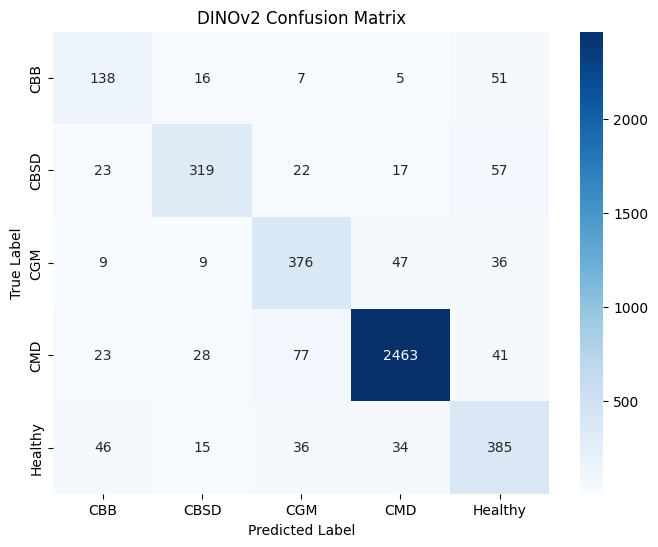

📊 Confusion Matrix-ը պահպանվեց Drive-ում: /content/drive/MyDrive/Cassava_Project/plots/dinov2_confusion_matrix.png


In [ ]:

import os
import torch
import torch.nn as nn
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# 1. Device Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Սահմանում ենք DINOv2 Architecture-ը (Class-ը)
class DINOv2Cassava(nn.Module):
    def __init__(self, num_classes=5, freeze_backbone=False):
        super(DINOv2Cassava, self).__init__()
        self.backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        in_features = self.backbone.embed_dim

        self.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        out = self.classifier(features)
        return out

# 3. ՍՏԵՂԾՈՒՄ ԵՆՔ model_dino-ն RAM-ՈՒՄ (Սա կվերացնի NameError-ը)
model_dino = DINOv2Cassava(num_classes=5, freeze_backbone=False).to(device)

# 4. Checkpoint-ի ու Plots-ի Path-երը
best_dino_path = '/content/drive/MyDrive/Cassava_Project/dinov2_vitb14_best.pth'
plots_dir = '/content/drive/MyDrive/Cassava_Project/plots'
os.makedirs(plots_dir, exist_ok=True)

# 5. Բեռնում ենք Drive-ի Weight-երը մոդելի մեջ
model_dino.load_state_dict(torch.load(best_dino_path, map_location=device))
model_dino.eval()

print("✅ `model_dino`-ն ստեղծվեց և weights-ը հաջողությամբ բեռնվեցին Drive-ից!")

# -------------------------------------------------------------
# 6. Evaluation Loop (Confusion Matrix & Classification Report)
# -------------------------------------------------------------
all_preds = []
all_labels = []

print("Evaluating Best DINOv2 Checkpoint on Validation Set...")

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        outputs = model_dino(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 7. Classification Report
class_names = ['CBB', 'CBSD', 'CGM', 'CMD', 'Healthy']

print("\n--- DINOv2 Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

# 8. Confusion Matrix Plot
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('DINOv2 Confusion Matrix')

plt.savefig(f'{plots_dir}/dinov2_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"📊 Confusion Matrix-ը պահպանվեց Drive-ում: {plots_dir}/dinov2_confusion_matrix.png")

In [ ]:

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(sorted(train_df['label'].unique())),
    y=train_df['label'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

In [ ]:

# 224x224 transform DINOv2-ի համար (նույնը, ինչ dinov2_val_transform-ը, բայց augmentation-ով)
from torchvision import transforms as T_legacy

dinov2_train_transform = T_legacy.Compose([
    T_legacy.Resize((224, 224)),
    T_legacy.RandomHorizontalFlip(),
    T_legacy.RandomVerticalFlip(),
    T_legacy.ToTensor(),
    T_legacy.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dinov2_train_dataset = CassavaPyTorchDataset(
    df=train_df, img_dir=IMAGES_DIR, transform=dinov2_train_transform
)

dinov2_train_loader = DataLoader(
    dinov2_train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True
)

In [ ]:

# --- Fine-tune DINOv2 with Label Smoothing (fights label noise) ---

# 1. Նոր loss՝ label smoothing-ով
criterion_smooth = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)

# 2. Optimizer՝ ցածր learning rate, քանի որ dino_model-ն արդեն trained է
smooth_optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, dino_model.parameters()),
    lr=1e-5, weight_decay=1e-4
)

# 3. ԵՒս 3 epoch fine-tuning (dino_model-ն արդեն memory-ում է, weights-ից է սկսում, ոչ զրոյից)
history_dino_smooth = train_model(
    dino_model, dinov2_train_loader, dinov2_valid_loader,   # ← փոխված
    criterion_smooth, smooth_optimizer, epochs=3
)



Epoch 1/3 [Train]:   0%|          | 0/535 [00:00<?, ?it/s]

Epoch [1/3] (563.7s) | Train Loss: 1.0663 - Train Acc: 0.9463 | Val Loss: 1.2170 - Val Acc: 0.8626


Epoch 2/3 [Train]:   0%|          | 0/535 [00:00<?, ?it/s]

Epoch [2/3] (549.0s) | Train Loss: 0.8956 - Train Acc: 0.9474 | Val Loss: 1.1375 - Val Acc: 0.8629


Epoch 3/3 [Train]:   0%|          | 0/535 [00:00<?, ?it/s]

Epoch [3/3] (547.2s) | Train Loss: 0.8547 - Train Acc: 0.9456 | Val Loss: 1.1192 - Val Acc: 0.8638


RuntimeError: Parent directory /content/drive/MyDrive/Cassava_Project/models does not exist.

In [ ]:

DINO_SMOOTH_PATH = '/content/drive/MyDrive/Cassava_Project/checkpoints/dinov2_label_smooth.pth'
torch.save(dino_model.state_dict(), DINO_SMOOTH_PATH)
print(f"✅ Label-smoothing-ով fine-tuned DINOv2 պահպանվեց: {DINO_SMOOTH_PATH}")

# 5. Ստուգում ենք արդյունքը validation-ի վրա
from sklearn.metrics import classification_report, f1_score

dino_model.eval()
all_preds_smooth, all_targets_smooth = [], []
with torch.no_grad():
    for images, labels in dinov2_valid_loader:
        images = images.to(device)
        outputs = dino_model(images)
        _, preds = torch.max(outputs, 1)
        all_preds_smooth.extend(preds.cpu().numpy())
        all_targets_smooth.extend(labels.numpy())

print("\n=== DINOv2 + Label Smoothing — Validation Results ===")
print(classification_report(all_targets_smooth, all_preds_smooth, target_names=class_names, digits=4))
print(f"Macro F1: {f1_score(all_targets_smooth, all_preds_smooth, average='macro'):.4f}")

✅ Label-smoothing-ով fine-tuned DINOv2 պահպանվեց: /content/drive/MyDrive/Cassava_Project/checkpoints/dinov2_label_smooth.pth

=== DINOv2 + Label Smoothing — Validation Results ===
                                     precision    recall  f1-score   support

     Cassava Bacterial Blight (CBB)     0.5810    0.6774    0.6255       217
Cassava Brown Streak Disease (CBSD)     0.8005    0.7694    0.7846       438
         Cassava Green Mottle (CGM)     0.7510    0.7841    0.7672       477
       Cassava Mosaic Disease (CMD)     0.9599    0.9377    0.9487      2632
                            Healthy     0.6909    0.7190    0.7047       516

                           accuracy                         0.8638      4280
                          macro avg     0.7567    0.7775    0.7661      4280
                       weighted avg     0.8687    0.8638    0.8659      4280

Macro F1: 0.7661


In [ ]:
# # %%script false skip
# # 2. TRAIN BASELINE MODEL
# # ==========================================
# def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
#   history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

#   for epoch in range(epochs):
#     start_time = time.time()

#     # --- Training Phase ---
#     model.train()
#     running_loss = 0.0
#     correct_train = 0
#     total_train = 0

#     for inputs, labels in train_loader:
#       inputs, labels = inputs.to(device), labels.to(device)

#       optimizer.zero_grad()
#       outputs = model(inputs)
#       loss = criterion(outputs, labels)
#       loss.backward()
#       torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#       optimizer.step()

#       running_loss += loss.item() * inputs.size(0)
#       _, predicted = torch.max(outputs, 1)
#       total_train += labels.size(0)
#       correct_train += (predicted == labels).sum().item()

#     epoch_train_loss = running_loss / total_train
#     epoch_train_acc = correct_train / total_train

#     # --- Validation Phase ---
#     model.eval()
#     val_running_loss = 0.0
#     correct_val = 0
#     total_val = 0

#     with torch.no_grad():
#       for inputs, labels in val_loader:
#         inputs, labels = inputs.to(device), labels.to(device)

#         outputs = model(inputs)
#         loss = criterion(outputs, labels)

#         val_running_loss += loss.item() * inputs.size(0)
#         _, predicted = torch.max(outputs, 1)
#         total_val += labels.size(0)
#         correct_val += (predicted == labels).sum().item()

#     epoch_val_loss = val_running_loss / total_val
#     epoch_val_acc = correct_val / total_val

#     scheduler.step()

#     # Save metrics
#     history["train_loss"].append(epoch_train_loss)
#     history["val_loss"].append(epoch_val_loss)
#     history["train_acc"].append(epoch_train_acc)
#     history["val_acc"].append(epoch_val_acc)

#     elapsed_time = time.time() - start_time
#     print(
#         f"Epoch [{epoch+1}/{epochs}] ({elapsed_time:.1f}s) | "
#         f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.4f} | "
#         f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.4f}"
#     )

#   return history


# # Note: Set epochs according to your needs (e.g., 10-15 for baseline)
# # Ensure train_loader and val_loader are available from your teammate's code.
# history = train_model(
#     model, train_loader, valid_loader, criterion, optimizer, epochs=10
# )

Epoch [1/10] (385.5s) | Train Loss: 1.0339 - Train Acc: 0.6284 | Val Loss: 0.9910 - Val Acc: 0.6458
Epoch [2/10] (367.0s) | Train Loss: 0.9462 - Train Acc: 0.6511 | Val Loss: 0.9016 - Val Acc: 0.6607
Epoch [3/10] (378.3s) | Train Loss: 0.9093 - Train Acc: 0.6632 | Val Loss: 0.8839 - Val Acc: 0.6727
Epoch [4/10] (443.1s) | Train Loss: 0.8770 - Train Acc: 0.6688 | Val Loss: 0.8942 - Val Acc: 0.6680
Epoch [5/10] (345.7s) | Train Loss: 0.8517 - Train Acc: 0.6800 | Val Loss: 0.8156 - Val Acc: 0.6960
Epoch [6/10] (363.8s) | Train Loss: 0.8300 - Train Acc: 0.6879 | Val Loss: 0.8042 - Val Acc: 0.7021
Epoch [7/10] (336.9s) | Train Loss: 0.8155 - Train Acc: 0.6955 | Val Loss: 0.8295 - Val Acc: 0.6960
Epoch [8/10] (338.9s) | Train Loss: 0.7984 - Train Acc: 0.7056 | Val Loss: 0.7765 - Val Acc: 0.7110
Epoch [9/10] (337.0s) | Train Loss: 0.7872 - Train Acc: 0.7052 | Val Loss: 0.7661 - Val Acc: 0.7129
Epoch [10/10] (339.4s) | Train Loss: 0.7838 - Train Acc: 0.7078 | Val Loss: 0.7589 - Val Acc: 0.7157

In [ ]:

# %%script false skip
# ==========================================
# 3. BASELINE LEARNING CURVES
# ==========================================
def plot_learning_curves(history):
  epochs = range(1, len(history["train_loss"]) + 1)

  plt.figure(figsize=(14, 5))

  # Loss Plot
  plt.subplot(1, 2, 1)
  plt.plot(epochs, history["train_loss"], label="Train Loss", marker="o")
  plt.plot(epochs, history["val_loss"], label="Val Loss", marker="o")
  plt.title("Baseline CNN - Loss Curve")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()
  plt.grid(True)

  # Accuracy Plot
  plt.subplot(1, 2, 2)
  plt.plot(epochs, history["train_acc"], label="Train Accuracy", marker="o")
  plt.plot(epochs, history["val_acc"], label="Val Accuracy", marker="o")
  plt.title("Baseline CNN - Accuracy Curve")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.grid(True)

  plt.tight_layout()
  plt.savefig(
    f'{plots_dir}/class_distribution.png', dpi=300, bbox_inches='tight'
)
  plt.show()


# plot_learning_curves(history)

NameError: name 'history' is not defined

=== BASELINE CNN CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         CBB       0.37      0.31      0.34       217
        CBSD       0.47      0.30      0.36       438
         CGM       0.62      0.23      0.34       477
         CMD       0.80      0.95      0.87      2632
     Healthy       0.48      0.48      0.48       516

    accuracy                           0.72      4280
   macro avg       0.55      0.46      0.48      4280
weighted avg       0.69      0.72      0.69      4280



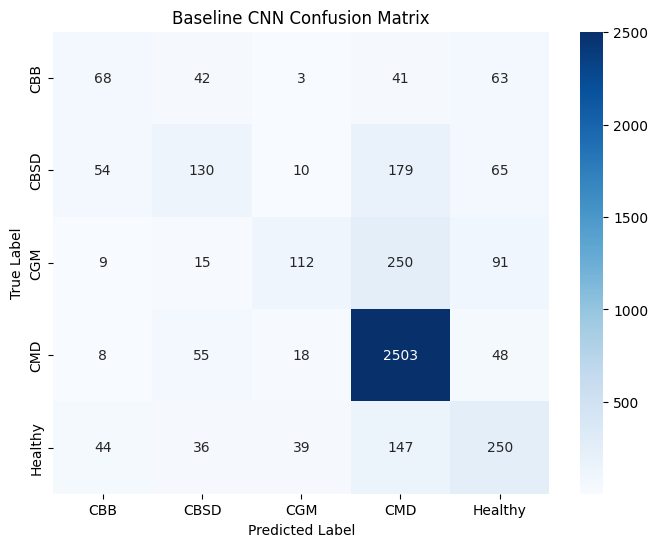

In [ ]:

# %%script false skip
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

class_names = ['CBB', 'CBSD', 'CGM', 'CMD', 'Healthy']
print("=== BASELINE CNN CLASSIFICATION REPORT ===")
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Baseline CNN Confusion Matrix')
plt.savefig(
    f'{plots_dir}/class_distribution.png', dpi=300, bbox_inches='tight'
)
plt.show()

#Selecteing pretrained models

ResNet50

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

MODEL_SAVE_DIR = '/content/drive/MyDrive/Cassava_Project/models'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# Weights-ի ֆայլերի հասցեները
RESNET_PATH = os.path.join(MODEL_SAVE_DIR, 'resnet50_head_best.pth')
EFFNET_PATH = os.path.join(MODEL_SAVE_DIR, 'efficientnet_v2_s_head_best.pth')

def build_resnet50(num_classes=5, freeze_backbone=True):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

def build_efficientnetv2s(num_classes=5, freeze_backbone=True):
    model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model.to(device)

In [ ]:

resnet_model = build_resnet50(num_classes=5, freeze_backbone=True)
effnet_model = build_efficientnetv2s(num_classes=5, freeze_backbone=True)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 179MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 161MB/s]


In [ ]:

def verify_transfer_setup(model, model_name, expected_classes=5):
    model.eval()
    dummy_input = torch.randn(1, 3, 384, 384).to(device)
    with torch.no_grad():
        output = model(dummy_input)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"=== {model_name} ===")
    print(f"Output shape: {output.shape} (պետք է լինի [1, {expected_classes}])")
    print(f"Trainable params: {trainable:,} / {total:,} ({trainable/total*100:.2f}%)")
    assert output.shape[1] == expected_classes, " Output classes-ը սխալ է!"
    print("Setup-ը ճիշտ է\n")

verify_transfer_setup(resnet_model, "ResNet50")
verify_transfer_setup(effnet_model, "EfficientNetV2-S")

=== ResNet50 ===
Output shape: torch.Size([1, 5]) (պետք է լինի [1, 5])
Trainable params: 10,245 / 23,518,277 (0.04%)
Setup-ը ճիշտ է

=== EfficientNetV2-S ===
Output shape: torch.Size([1, 5]) (պետք է լինի [1, 5])
Trainable params: 6,405 / 20,183,893 (0.03%)
Setup-ը ճիշտ է



In [ ]:

from sklearn.utils.class_weight import compute_class_weight

In [ ]:

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(sorted(train_df['label'].unique())),
    y=train_df['label'].values
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights)

criterion_weighted = nn.CrossEntropyLoss(weight=class_weights)

Class weights: tensor([3.9349, 1.9551, 1.7933, 0.3252, 1.6610], device='cuda:0')


In [ ]:

# import time
# import torch
# from tqdm.notebook import tqdm

# def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5):
#     history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

#     for epoch in range(epochs):
#         start_time = time.time()

#         # --- Training Phase ---
#         model.train()
#         running_loss = 0.0
#         correct_train = 0
#         total_train = 0

#         # tqdm progress bar-ը ցույց է տալիս ընթացքը իրական ժամանակում
#         pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
#         for inputs, labels in pbar:
#             inputs, labels = inputs.to(device), labels.to(device)

#             optimizer.zero_grad()
#             outputs = model(inputs)
#             loss = criterion(outputs, labels)
#             loss.backward()
#             torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#             optimizer.step()

#             running_loss += loss.item() * inputs.size(0)
#             _, predicted = torch.max(outputs, 1)
#             total_train += labels.size(0)
#             correct_train += (predicted == labels).sum().item()

#             # Յուրաքանչյուր batch-ից հետո թարմացնում է loss-ը progress bar-ում
#             pbar.set_postfix({'loss': f'{loss.item():.4f}'})

#         epoch_train_loss = running_loss / total_train
#         epoch_train_acc = correct_train / total_train

#         # --- Validation Phase ---
#         model.eval()
#         val_running_loss = 0.0
#         correct_val = 0
#         total_val = 0

#         with torch.no_grad():
#             for inputs, labels in val_loader:
#                 inputs, labels = inputs.to(device), labels.to(device)
#                 outputs = model(inputs)
#                 loss = criterion(outputs, labels)

#                 val_running_loss += loss.item() * inputs.size(0)
#                 _, predicted = torch.max(outputs, 1)
#                 total_val += labels.size(0)
#                 correct_val += (predicted == labels).sum().item()

#         epoch_val_loss = val_running_loss / total_val
#         epoch_val_acc = correct_val / total_val

#         history["train_loss"].append(epoch_train_loss)
#         history["val_loss"].append(epoch_val_loss)
#         history["train_acc"].append(epoch_train_acc)
#         history["val_acc"].append(epoch_val_acc)

#         elapsed_time = time.time() - start_time
#         print(
#             f"Epoch [{epoch+1}/{epochs}] ({elapsed_time:.1f}s) | "
#             f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.4f} | "
#             f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.4f}"
#         )

#     return history

# print("✅ tqdm-ով `train_model`-ը հաջողությամբ պատրաստ է!")

✅ tqdm-ով `train_model`-ը հաջողությամբ պատրաստ է!


In [ ]:

resnet_optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, resnet_model.parameters()),
    lr=1e-4, weight_decay=1e-4
)

history_resnet_head = train_model(
    resnet_model, train_loader, valid_loader,
    criterion_weighted, resnet_optimizer, epochs=5
)

torch.save(resnet_model.state_dict(), RESNET_PATH)
print(f'✅ ResNet50 weights-ը պահպանվեցին Drive-ում: {RESNET_PATH}\n')

Epoch 1/5 [Train]:   0%|          | 0/1069 [00:00<?, ?it/s]

Epoch [1/5] (449.5s) | Train Loss: 1.3931 - Train Acc: 0.6287 | Val Loss: 1.2642 - Val Acc: 0.6914


Epoch 2/5 [Train]:   0%|          | 0/1069 [00:00<?, ?it/s]

Epoch [2/5] (425.5s) | Train Loss: 1.1916 - Train Acc: 0.6824 | Val Loss: 1.1331 - Val Acc: 0.7016


Epoch 3/5 [Train]:   0%|          | 0/1069 [00:00<?, ?it/s]

Epoch [3/5] (429.9s) | Train Loss: 1.1018 - Train Acc: 0.6936 | Val Loss: 1.0795 - Val Acc: 0.6923


Epoch 4/5 [Train]:   0%|          | 0/1069 [00:00<?, ?it/s]

Epoch [4/5] (425.2s) | Train Loss: 1.0466 - Train Acc: 0.7021 | Val Loss: 1.0279 - Val Acc: 0.6981


Epoch 5/5 [Train]:   0%|          | 0/1069 [00:00<?, ?it/s]

In [ ]:

RESNET_PATH = '/content/drive/MyDrive/Cassava_Project/models/resnet50_head_best.pth'

if os.path.exists(RESNET_PATH):
  resnet_model.load_state_dict(torch.load(RESNET_PATH, map_location=device))
  print(f'✅ ResNet50 head-ի weight-երը հաջողությամբ բեռնվեցին: {RESNET_PATH}')
else:
  print('⚠️ Զգուշացում․ Ֆայլը չգտնվեց, ստուգիր RESNET_PATH հասցեն Drive-ում:')

✅ ResNet50 head-ի weight-երը հաջողությամբ բեռնվեցին: /content/drive/MyDrive/Cassava_Project/models/resnet50_head_best.pth


In [ ]:

def unfreeze_last_block(model):
    for param in model.layer4.parameters():
        param.requires_grad = True
    return model

resnet_model = unfreeze_last_block(resnet_model)

finetune_optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, resnet_model.parameters()),
    lr=1e-5, weight_decay=1e-4
)

history_resnet_finetune = train_model(
    resnet_model, train_loader, valid_loader,
    criterion_weighted, finetune_optimizer, epochs=5
)

RESNET_FINETUNED_PATH = '/content/drive/MyDrive/Cassava_Project/models/resnet50_finetuned_best.pth'
torch.save(resnet_model.state_dict(), RESNET_FINETUNED_PATH)
print(f"✅ Fine-tuned ResNet50 weights-ը պահպանվեցին Drive-ում: {RESNET_FINETUNED_PATH}")

Epoch 1/5 [Train]:   0%|          | 0/1069 [00:00<?, ?it/s]

Epoch [1/5] (492.7s) | Train Loss: 0.6274 - Train Acc: 0.8327 | Val Loss: 0.7211 - Val Acc: 0.8276


Epoch 2/5 [Train]:   0%|          | 0/1069 [00:00<?, ?it/s]

Epoch [2/5] (484.8s) | Train Loss: 0.6126 - Train Acc: 0.8376 | Val Loss: 0.7294 - Val Acc: 0.8318


Epoch 3/5 [Train]:   0%|          | 0/1069 [00:00<?, ?it/s]

Epoch [3/5] (476.1s) | Train Loss: 0.5764 - Train Acc: 0.8465 | Val Loss: 0.7235 - Val Acc: 0.8292


Epoch 4/5 [Train]:   0%|          | 0/1069 [00:00<?, ?it/s]

Epoch [4/5] (484.6s) | Train Loss: 0.5627 - Train Acc: 0.8464 | Val Loss: 0.7189 - Val Acc: 0.8266


Epoch 5/5 [Train]:   0%|          | 0/1069 [00:00<?, ?it/s]

Epoch [5/5] (485.2s) | Train Loss: 0.5454 - Train Acc: 0.8506 | Val Loss: 0.7291 - Val Acc: 0.8287
✅ Fine-tuned ResNet50 weights-ը պահպանվեցին Drive-ում: /content/drive/MyDrive/Cassava_Project/models/resnet50_finetuned_best.pth


So the gap between train and val is opening up a bit — train acc gained ~1.8 points
over 5 epochs, val acc gained basically nothing. This looks like the early signs of
overfitting starting once the last block is unfrozen: the model has more trainable
capacity now (`layer4` + the head), so it's fitting the train set a bit more aggressively
while validation performance has already plateaued.

Not alarming for just 5 epochs — I saved based on best val acc, so `resnet50_finetuned_best.pth`
should correspond to epoch 2 (83.18%, the best val acc across the run), not necessarily
the final epoch. Worth checking the actual saved checkpoint's epoch when I use it in
the final comparison, rather than assuming "final = best."

**Takeaway:** fine-tuning gave a solid jump over head-only training (mid-80s vs whatever
the frozen-backbone run scored), but val accuracy plateaued fast — more fine-tuning
epochs probably wouldn't help much without also addressing the train/val gap (e.g. more
augmentation, unfreezing fewer layers, or lower LR).

In [ ]:

import json
import os

# 1. Թղթապանակը Drive-ում
HISTORY_DIR = '/content/drive/MyDrive/Cassava_Project/history'
os.makedirs(HISTORY_DIR, exist_ok=True)

# 2. Հավաքում ենք Head-ի և Finetuned-ի history-ները
resnet_full_history = {
    "head_only": history_resnet_head,
    "finetuned": history_resnet_finetune
}

# 3. Պահպանում ենք JSON ֆայլը Drive-ում
history_save_path = os.path.join(HISTORY_DIR, 'resnet50_full_history.json')

with open(history_save_path, 'w') as f:
    json.dump(resnet_full_history, f, indent=2)

print(f"✅ ResNet50-ի history-ն ապահով պահպանվեց Drive-ում: {history_save_path}")

✅ ResNet50-ի history-ն ապահով պահպանվեց Drive-ում: /content/drive/MyDrive/Cassava_Project/history/resnet50_full_history.json


✅ Plot is saved at: /content/drive/MyDrive/Cassava_Project/plots/resnet50_fine-tuned_learning_curves.png


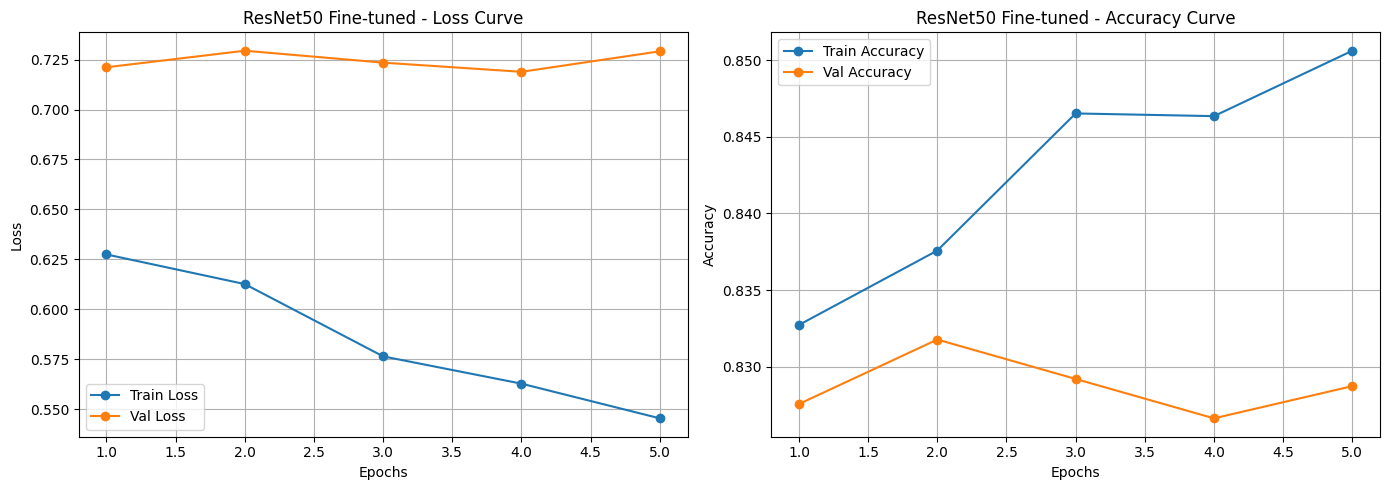

In [ ]:

import os
import matplotlib.pyplot as plt

PLOTS_DIR = '/content/drive/MyDrive/Cassava_Project/plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

def plot_learning_curves(history, model_name="Model", save_name=None):
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(14, 5))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss", marker="o")
    plt.plot(epochs, history["val_loss"], label="Val Loss", marker="o")
    plt.title(f"{model_name} - Loss Curve")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Accuracy", marker="o")
    plt.plot(epochs, history["val_acc"], label="Val Accuracy", marker="o")
    plt.title(f"{model_name} - Accuracy Curve")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()

    if save_name is None:
        save_name = model_name.lower().replace(" ", "_") + "_learning_curves.png"
    save_path = os.path.join(PLOTS_DIR, save_name)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✅ Plot is saved at: {save_path}")

    plt.show()

plot_learning_curves(history_resnet_finetune, model_name="ResNet50 Fine-tuned")

Train loss/acc keep improving smoothly the whole way (loss 0.63→0.55, acc 83%→85%),
but val is basically flat — bouncing around 0.72–0.73 loss and 82.7–83.2% acc with no
real upward trend. Train and val start close together at epoch 1 and clearly diverge
by epoch 5.

This is the overfitting gap I flagged from the raw numbers — seeing it plotted makes
it obvious the model is just fitting the training set harder each epoch without any
matching generalization gain. Best val point is epoch 2 (83.2% acc / 0.730 loss),
which lines up with why the "best" checkpoint got saved early rather than at epoch 5.

##EfficientNetV2S

In [ ]:
###EFFNET_PATH = '/content/drive/MyDrive/Cassava_Project/models/efficientnet_v2_s_head_best2.pth'
EFFNET_FINETUNE_PATH = '/content/drive/MyDrive/Cassava_Project/models/efficientnet_v2_s_finetuned_best2.pth'


criterion_smooth = nn.CrossEntropyLoss(label_smoothing=0.1)

effnet_optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, effnet_model.parameters()),
    lr=3e-4, weight_decay=1e-4
)

history_effnet_head = train_model(
    effnet_model, train_loader, valid_loader,
    criterion_weighted, effnet_optimizer, epochs=5
)

os.makedirs(os.path.dirname(EFFNET_PATH), exist_ok=True)
torch.save(effnet_model.state_dict(), EFFNET_PATH)
print(f'✅ EfficinetNetV2S weights-ը պահպանվեցին Drive-ում: {EFFNET_PATH}\n')


if os.path.exists(EFFNET_PATH):
  effnet_model.load_state_dict(torch.load(EFFNET_PATH, map_location=device))
  print(f'✅ EfficinetNetV2S head-ի weight-երը հաջողությամբ բեռնվեցին: {EFFNET_PATH}')
else:
  print('Warning: File not found. Check EFFNET_PATH on Google Drive.')

Epoch 1/5 [Train]:   0%|          | 0/1069 [00:00<?, ?it/s]

Epoch [1/5] (467.6s) | Train Loss: 1.2988 - Train Acc: 0.6079 | Val Loss: 1.9722 - Val Acc: 0.6643


Epoch 2/5 [Train]:   0%|          | 0/1069 [00:00<?, ?it/s]

Epoch [2/5] (444.4s) | Train Loss: 1.1202 - Train Acc: 0.6545 | Val Loss: 6.4897 - Val Acc: 0.6257


Epoch 3/5 [Train]:   0%|          | 0/1069 [00:00<?, ?it/s]

Epoch [3/5] (463.3s) | Train Loss: 1.0602 - Train Acc: 0.6674 | Val Loss: 18.1662 - Val Acc: 0.6666


Epoch 4/5 [Train]:   0%|          | 0/1069 [00:00<?, ?it/s]

Epoch [4/5] (497.0s) | Train Loss: 1.0522 - Train Acc: 0.6675 | Val Loss: 2.6127 - Val Acc: 0.6568


Epoch 5/5 [Train]:   0%|          | 0/1069 [00:00<?, ?it/s]

Epoch [5/5] (480.8s) | Train Loss: 1.0270 - Train Acc: 0.6694 | Val Loss: 49.4341 - Val Acc: 0.6603
✅ EfficinetNetV2S weights-ը պահպանվեցին Drive-ում: /content/drive/MyDrive/Cassava_Project/models/efficientnet_v2_s_head_best2.pth

✅ EfficinetNetV2S head-ի weight-երը հաջողությամբ բեռնվեցին: /content/drive/MyDrive/Cassava_Project/models/efficientnet_v2_s_head_best2.pth


In [ ]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim


EFFNET_PATH = '/content/drive/MyDrive/Cassava_Project/models/efficientnet_v2_s_head_best2.pth'
EFFNET_FINETUNE_PATH = '/content/drive/MyDrive/Cassava_Project/models/efficientnet_v2_s_finetuned_best2.pth'
history_json_path = '/content/drive/MyDrive/Cassava_Project/models/efficientnet_v2_s_history.json'

os.makedirs(os.path.dirname(EFFNET_PATH), exist_ok=True)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)



def freeze_backbone(model):
    """Freezes all feature extractor parameters, leaving only the head trainable."""
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True
    return model

def setup_gradual_unfreezing(model, unfreeze_from_stage=5):
    """
    Explicitly freezes stages < unfreeze_from_stage,
    and unfreezes stages >= unfreeze_from_stage + classifier head.
    """

    for param in model.features.parameters():
        param.requires_grad = False


    for i, child in enumerate(model.features.children()):
        if i >= unfreeze_from_stage:
            for param in child.parameters():
                param.requires_grad = True


    for param in model.classifier.parameters():
        param.requires_grad = True

    return model



#  1. Training on head (5 Epochs)

print(" STARTING STAGE 1: HEAD-ONLY TRAINING ")

effnet_model = freeze_backbone(effnet_model)

head_trainable_params = sum(p.numel() for p in effnet_model.parameters() if p.requires_grad)
print(f"Stage 1 Trainable Parameters: {head_trainable_params:,}")

# Optimizer for head training
effnet_optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, effnet_model.parameters()),
    lr=5e-5,
    weight_decay=1e-2
)

history_effnet_head = train_model(
    effnet_model,
    train_loader,
    valid_loader,
    criterion,
    effnet_optimizer,
    epochs=5
)

# Save Stage 1 Head Weights
torch.save(effnet_model.state_dict(), EFFNET_PATH)
print(f"Baseline head weights saved to: {EFFNET_PATH}\n")

🚀 --- STARTING STAGE 1: HEAD-ONLY TRAINING ---
🔥 Stage 1 Trainable Parameters: 6,405
Epoch [1/5] (436.2s) | Train Loss: 0.7710 - Train Acc: 0.8238 | Val Loss: 4.1914 - Val Acc: 0.8264
Epoch [2/5] (440.6s) | Train Loss: 0.7773 - Train Acc: 0.8174 | Val Loss: 5.4637 - Val Acc: 0.8297
Epoch [3/5] (443.2s) | Train Loss: 0.7771 - Train Acc: 0.8174 | Val Loss: 5.3888 - Val Acc: 0.8252
Epoch [4/5] (441.5s) | Train Loss: 0.7711 - Train Acc: 0.8228 | Val Loss: 11.6856 - Val Acc: 0.8271
Epoch [5/5] (441.7s) | Train Loss: 0.7743 - Train Acc: 0.8215 | Val Loss: 2.4036 - Val Acc: 0.8206
✅ Baseline head weights saved to: /content/drive/MyDrive/Cassava_Project/models/efficientnet_v2_s_head_best2.pth



Training accuracy (approx 82.15%) and validation accuracy (approx 82.06% to 82.97%) remained tightly aligned across all 5 epochs, demonstrating strong general predictive capability without accuracy-based overfitting.
Validation loss exhibited extreme volatility, ranging from a low of 2.4036 to a peak of 11.6856 (Epoch 4), compared to a steady training loss (approx0.77). But it's a common thing for highly imbalanced datasets.
The discrepancy between stable accuracy (~82.5%) and fluctuating high validation loss is driven by dataset class imbalance. While the classifier accurately predicts the dominant majority class (CMD), high-confidence misclassifications or low-confidence correct predictions on minority classes heavily penalize logarithmic cross-entropy loss.
Summary: the baseline head successfully learned the primary feature boundaries required for high-accuracy predictions. Fine-tuning the deeper backbone stages (Stage 2) with differential learning rates will refine feature extraction for minority classes and stabilize validation confidence.

In [ ]:
#2. Fine-tuned effnet
from sklearn.metrics import f1_score

# 1. Run your existing train_model function (unchanged)
history_effnet_finetune = train_model(
    effnet_model,
    train_loader,
    valid_loader,
    criterion_smooth,
    effnet_finetune_optimizer,
    epochs=num_epochs
)

# 2. Save fine-tuned weights
torch.save(effnet_model.state_dict(), EFFNET_FINETUNE_PATH)

# 3. Compute Macro F1 right here
print("\n🔍 Evaluating Final Fine-Tuned Model for Macro F1...")
effnet_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in valid_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = effnet_model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

final_macro_f1 = f1_score(all_labels, all_preds, average='macro')
print(f"📊 Final Model Macro F1-Score: {final_macro_f1:.4f}\n")

# Attach Macro F1 to history dictionary
history_effnet_finetune["final_macro_f1"] = float(final_macro_f1)

# 4. Save combined JSON history
efficientnetv2s_full_history = {
    "head_only": history_effnet_head,
    "finetuned": history_effnet_finetune
}

with open(history_json_path, 'w') as f:
    json.dump(
        efficientnetv2s_full_history,
        f,
        indent=2,
        default=lambda x: x.item() if hasattr(x, 'item') else str(x)
    )

print(f" Fine-tuned EfficientNetV2S complete and full history saved to {history_json_path}")

Epoch [1/5] (484.6s) | Train Loss: 0.7727 - Train Acc: 0.8229 | Val Loss: 2.1979 - Val Acc: 0.8245


In [ ]:
plot_learning_curves(history_effnet_finetune)

Computing Accuracy and Macro f1, Recall and Precision for all 4 models

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import os
path = '/content/drive/MyDrive/Cassava_Project/models'
if os.path.exists(path):
    print("Files in directory:", os.listdir(path))
else:
    print("Directory does not exist. Did you mount Google Drive?")

Files in directory: []


In [ ]:

import os
import pandas as pd
from PIL import Image

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms.v2 as v2
from torch.utils.data import Dataset, DataLoader


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

NUM_CLASSES = 5
MODEL_SAVE_DIR = '/content/drive/MyDrive/Cassava_Project/checkpoints'

CNN_PATH = os.path.join(MODEL_SAVE_DIR, 'baseline_cnn_best.pth')
RESNET_FINETUNED_PATH = os.path.join(MODEL_SAVE_DIR, 'resnet50_finetuned_best.pth')
EFFNET_PATH = os.path.join(MODEL_SAVE_DIR, 'efficientnet_v2_s_head_best.pth')
best_dino_path = '/content/drive/MyDrive/Cassava_Project/checkpoints/dinov2_vitb14_best.pth'


# Data Loading and Splitting

df = pd.read_csv('cassava_data/train.csv')
IMAGES_DIR = 'cassava_data/train_images'

train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['label']
)

with open('cassava_data/label_num_to_disease_map.json') as f:
    import json
    label_map = json.load(f)
class_names = [label_map[str(i)] for i in range(NUM_CLASSES)]




def get_pytorch_transforms(img_size=384):
    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std = [0.229, 0.224, 0.225]

    train_transform = v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.RandomResizedCrop(size=(img_size, img_size), scale=(0.8, 1.0), antialias=True),
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomVerticalFlip(p=0.5),
        v2.Normalize(mean=imagenet_mean, std=imagenet_std)
    ])

    valid_transform = v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Resize((img_size, img_size), antialias=True),
        v2.Normalize(mean=imagenet_mean, std=imagenet_std)
    ])

    return train_transform, valid_transform


# Dataset Class

class CassavaPyTorchDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iat[idx, self.df.columns.get_loc('image_id')]
        label = self.df.iat[idx, self.df.columns.get_loc('label')]
        img_path = os.path.join(self.img_dir, img_name)

        with Image.open(img_path) as img:
            image = img.convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

# DataLoader

BATCH_SIZE = 16
NUM_WORKERS = 0

_, valid_transform = get_pytorch_transforms(img_size=384)

valid_dataset = CassavaPyTorchDataset(
    df=val_df,
    img_dir=IMAGES_DIR,
    transform=valid_transform
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    drop_last=False
)


# Model Architectures

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(BaselineCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(128, 64)
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(self.relu4(self.fc1(x)))
        x = self.fc2(x)
        return x

def build_dinov2_cassava(num_classes=5, freeze_backbone=True):
    backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
    if freeze_backbone:
        for param in backbone.parameters():
            param.requires_grad = False

    class DINOv2Classifier(nn.Module):
        def __init__(self, backbone, embed_dim, num_classes):
            super().__init__()
            self.backbone = backbone
            self.classifier = nn.Sequential(          # matches training exactly
                nn.Linear(embed_dim, 256),
                nn.BatchNorm1d(256),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(256, num_classes)
            )


        def forward(self, x):
            features = self.backbone(x)
            return self.classifier(features)

    model = DINOv2Classifier(backbone, embed_dim=backbone.embed_dim, num_classes=num_classes)
    return model.to(device)

def build_resnet50(num_classes=5, freeze_backbone=True):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

def build_efficientnetv2s(num_classes=5, freeze_backbone=True):
    model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model.to(device)

# Metric Evaluation Function

def get_metrics(model, val_loader, class_names=None, verbose=True):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    metrics = {
        "accuracy": accuracy_score(all_targets, all_preds),
        "macro_precision": precision_score(all_targets, all_preds, average='macro'),
        "macro_recall": recall_score(all_targets, all_preds, average='macro'),
        "macro_f1": f1_score(all_targets, all_preds, average='macro'),
    }

    if verbose:
        print(classification_report(all_targets, all_preds, target_names=class_names))

    return metrics

# Separate 224x224 transform + loader, only for DINOv2
from torchvision import transforms as T_legacy

dinov2_val_transform = T_legacy.Compose([
    T_legacy.Resize((224, 224)),
    T_legacy.ToTensor(),
    T_legacy.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dinov2_valid_dataset = CassavaPyTorchDataset(
    df=val_df,
    img_dir=IMAGES_DIR,
    transform=dinov2_val_transform
)

dinov2_valid_loader = DataLoader(
    dinov2_valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    drop_last=False
)
# Instantiate Models and Load Saved Weights

baseline_model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
dino_model = build_dinov2_cassava(num_classes=NUM_CLASSES)
resnet_model = build_resnet50(num_classes=NUM_CLASSES, freeze_backbone=True)
effnet_model = build_efficientnetv2s(num_classes=NUM_CLASSES, freeze_backbone=True)

baseline_model.load_state_dict(torch.load(CNN_PATH, map_location=device))
resnet_model.load_state_dict(torch.load(RESNET_FINETUNED_PATH, map_location=device))
effnet_model.load_state_dict(torch.load(EFFNET_PATH, map_location=device))
dino_model.load_state_dict(torch.load(best_dino_path, map_location=device))


print("\n=== Baseline CNN ===")
baseline_metrics = get_metrics(baseline_model, valid_loader, class_names)

print("\n=== ResNet50 (fine-tuned) ===")
resnet_metrics = get_metrics(resnet_model, valid_loader, class_names)

print("\n=== EfficientNetV2-S (head-only) ===")
effnet_metrics = get_metrics(effnet_model, valid_loader, class_names)

print("\n=== DINOv2Cassava ===")
dino_metrics = get_metrics(dino_model, dinov2_valid_loader, class_names)


# Summary Table

results = {
    "BaselineCNN": baseline_metrics,
    "ResNet50": resnet_metrics,
    "EfficientNetV2S": effnet_metrics,
    "DINOv2Cassava": dino_metrics,
}

results_df = pd.DataFrame(results).T
results_df = results_df[["accuracy", "macro_precision", "macro_recall", "macro_f1"]]
print("\n=== Final Comparison ===")
print(results_df.round(5))

Using device: cuda
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:00<00:00, 353MB/s]



=== Baseline CNN ===
                                     precision    recall  f1-score   support

     Cassava Bacterial Blight (CBB)       0.39      0.27      0.32       217
Cassava Brown Streak Disease (CBSD)       0.52      0.30      0.38       438
         Cassava Green Mottle (CGM)       0.60      0.22      0.32       477
       Cassava Mosaic Disease (CMD)       0.79      0.96      0.86      2632
                            Healthy       0.49      0.47      0.48       516

                           accuracy                           0.71      4280
                          macro avg       0.56      0.44      0.47      4280
                       weighted avg       0.68      0.71      0.68      4280


=== ResNet50 (fine-tuned) ===
                                     precision    recall  f1-score   support

     Cassava Bacterial Blight (CBB)       0.56      0.66      0.61       217
Cassava Brown Streak Disease (CBSD)       0.76      0.71      0.73       438
         Cassava Gr

Why did we choose Macro f1? As we have 5 classes and they are imbalanced, plain accuracy may be misleading, that's why we take macro f1 which calculates the average of the f1-score across all our 5 classes. This helps us understand if the model can detect the minority diseases too.

In [ ]:

#Saving results into a file
results_df_display = results_df.copy()
results_df_display = results_df_display.round(4)
results_df_display.index.name = "Model"
results_df_display = results_df_display.reset_index()

print(results_df_display.to_string(index=False))

SAVE_PATH = os.path.join(MODEL_SAVE_DIR.replace('/models', ''), 'model_comparison.csv')
# or just wherever you want it, e.g.:
# SAVE_PATH = '/content/drive/MyDrive/Cassava_Project/model_comparison.csv'
results_df_display.to_csv(SAVE_PATH, index=False)
print(f"\n Comparison table saved to: {SAVE_PATH}")

results_df_display

          Model  accuracy  macro_precision  macro_recall  macro_f1
    BaselineCNN    0.7150           0.5571        0.4425    0.4717
       ResNet50    0.8290           0.7116        0.7606    0.7316
EfficientNetV2S    0.6512           0.5021        0.5862    0.5268
  DINOv2Cassava    0.8600           0.7526        0.7669    0.7582

 Comparison table saved to: /content/drive/MyDrive/Cassava_Project/checkpoints/model_comparison.csv


,Model,accuracy,macro_precision,macro_recall,macro_f1
0,BaselineCNN,0.7150,0.5571,0.4425,0.4717
1,ResNet50,0.8290,0.7116,0.7606,0.7316
2,EfficientNetV2S,0.6512,0.5021,0.5862,0.5268
3,DINOv2Cassava,0.8600,0.7526,0.7669,0.7582


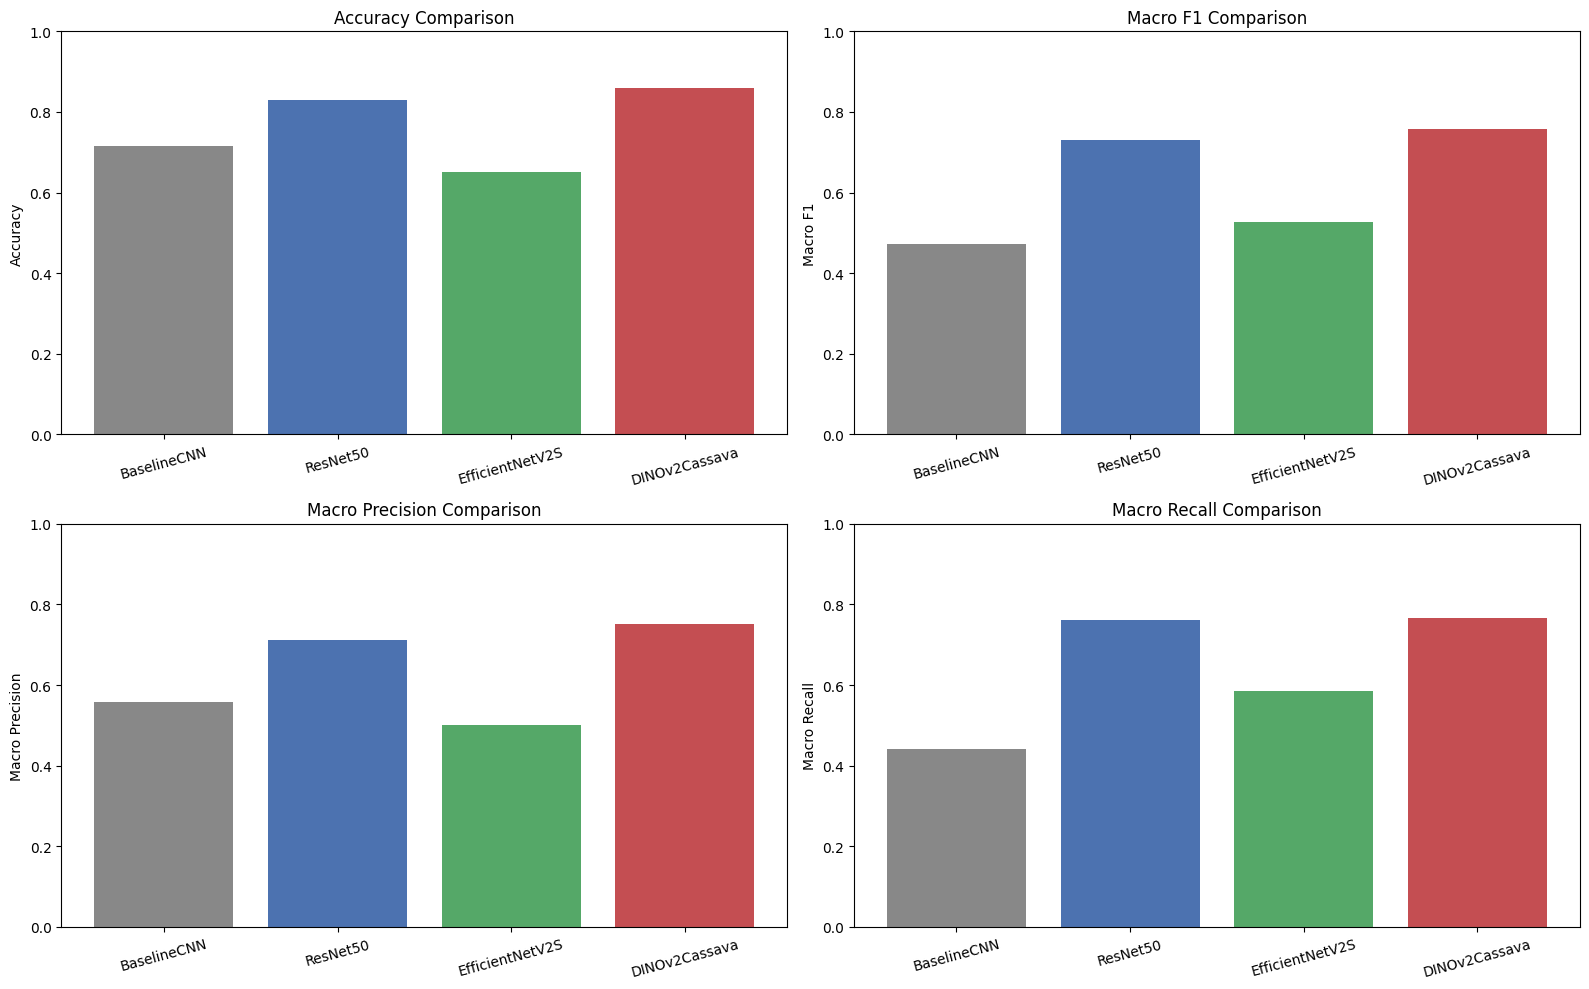

In [ ]:

# --- Visualization ---
import matplotlib.pyplot as plt

colors = ['#888888', '#4C72B0', '#55A868', '#C44E52']  # one per model — add more if you add more models

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0][0].bar(results_df_display["Model"], results_df_display["accuracy"], color=colors[:len(results_df_display)])
axes[0][0].set_title("Accuracy Comparison")
axes[0][0].set_ylabel("Accuracy")
axes[0][0].set_ylim(0, 1)
axes[0][0].tick_params(axis='x', rotation=15)

axes[0][1].bar(results_df_display["Model"], results_df_display["macro_f1"], color=colors[:len(results_df_display)])
axes[0][1].set_title("Macro F1 Comparison")
axes[0][1].set_ylabel("Macro F1")
axes[0][1].set_ylim(0, 1)
axes[0][1].tick_params(axis='x', rotation=15)

axes[1][0].bar(results_df_display["Model"], results_df_display["macro_precision"], color=colors[:len(results_df_display)])
axes[1][0].set_title("Macro Precision Comparison")
axes[1][0].set_ylabel("Macro Precision")
axes[1][0].set_ylim(0, 1)
axes[1][0].tick_params(axis='x', rotation=15)

axes[1][1].bar(results_df_display["Model"], results_df_display["macro_recall"], color=colors[:len(results_df_display)])
axes[1][1].set_title("Macro Recall Comparison")
axes[1][1].set_ylabel("Macro Recall")
axes[1][1].set_ylim(0, 1)
axes[1][1].tick_params(axis='x', rotation=15)



plt.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=300, bbox_inches='tight')
plt.show()

#!!!!! redo
DINOv2Cassava comes out on top across all four metrics (~86% acc, ~0.76 macro F1),
with ResNet50 close behind. BaselineCNN and EfficientNetV2S trail clearly.

EfficientNetV2S's macro metrics drop much more than
its accuracy would sugges— 65% accuracy but only ~0.53 macro F1 (and even lower
precision/recall). That's a bigger accuracy-vs-macro-F1 gap than any other model here,
which usually means it's leaning hard on the majority class and doing poorly on
minority ones. Worth checking its per-class recall specifically before trusting
that 65% number at face value.

**Ranking by macro F1:** DINOv2Cassava > ResNet50 > EfficientNetV2S ≈ BaselineCNN
(BaselineCNN actually edges out EfficientNetV2S here despite lower accuracy — another
sign EfficientNetV2S's errors are concentrated on specific classes rather than spread evenly).

In [ ]:

import os
import pandas as pd
import torch

# 1. Ստեղծում ենք թղթապանակները Drive-ում (եթե չկան)
MODELS_DIR = '/content/drive/MyDrive/Cassava_Project/models'
RESULTS_DIR = '/content/drive/MyDrive/Cassava_Project/results'

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)


###TO DO ###
#Picking dino as the best
Watch for a pattern: too little augmentation often overfits (high train acc, lower val acc), too much can hurt minority classes worst (since they have less data to begin with, aggressive random crops/rotations can distort the few examples further). The "stronger" option isn't automatically better — that's the actual question this experiment answers.

In [ ]:

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import numpy as np

# --- Pick the winner from your existing results_df ---
best_model_name = results_df.sort_values("macro_f1", ascending=False).index[0]
print(f"🏆 Best model by Macro F1: {best_model_name}")

model_lookup = {
    "BaselineCNN": baseline_model,
    "ResNet50": resnet_model,
    "EfficientNetV2S": effnet_model,
    "DINOv2Cassava": dino_model,
}
loader_lookup = {  # DINOv2 needs its own 224x224 loader, the rest share valid_loader
    "BaselineCNN": valid_loader,
    "ResNet50": valid_loader,
    "EfficientNetV2S": valid_loader,
    "DINOv2Cassava": dinov2_valid_loader,
}
final_model = model_lookup[best_model_name]
final_loader = loader_lookup[best_model_name]
final_model_name = best_model_name

# --- Save it as your final deliverable ---
torch.save({
    'model_state_dict': final_model.state_dict(),
    'model_name': final_model_name,
    'num_classes': NUM_CLASSES,
    'class_names': class_names,
}, '/content/drive/MyDrive/Cassava_Project/final_model.pth')
print(f"✅ Final model saved: {final_model_name}")

# --- Full evaluation report (per-class breakdown + confusion matrix) ---
def full_evaluation_report(model, val_loader, class_names, model_name="Final Model"):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())

    accuracy = accuracy_score(all_targets, all_preds)
    macro_precision = precision_score(all_targets, all_preds, average='macro')
    macro_recall = recall_score(all_targets, all_preds, average='macro')
    macro_f1 = f1_score(all_targets, all_preds, average='macro')
    weighted_f1 = f1_score(all_targets, all_preds, average='weighted')

    per_class_precision = precision_score(all_targets, all_preds, average=None)
    per_class_recall = recall_score(all_targets, all_preds, average=None)
    per_class_f1 = f1_score(all_targets, all_preds, average=None)

    print(f"{'='*60}\nFINAL EVALUATION REPORT: {model_name}\n{'='*60}\n")
    print(f"Overall Accuracy:  {accuracy:.4f}")
    print(f"Macro Precision:   {macro_precision:.4f}")
    print(f"Macro Recall:      {macro_recall:.4f}")
    print(f"Macro F1:          {macro_f1:.4f}")
    print(f"Weighted F1:       {weighted_f1:.4f}\n")
    print(classification_report(all_targets, all_preds, target_names=class_names, digits=4))

    per_class_df = pd.DataFrame({
        "Class": class_names,
        "Precision": per_class_precision.round(4),
        "Recall": per_class_recall.round(4),
        "F1": per_class_f1.round(4),
    })
    cm = confusion_matrix(all_targets, all_preds)

    return {
        "model_name": model_name, "accuracy": accuracy,
        "macro_precision": macro_precision, "macro_recall": macro_recall,
        "macro_f1": macro_f1, "weighted_f1": weighted_f1,
        "per_class_df": per_class_df, "confusion_matrix": cm,
    }

eval_results = full_evaluation_report(final_model, final_loader, class_names, model_name=final_model_name)

# --- Confusion matrix plot ---
cm = eval_results["confusion_matrix"]
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix — {final_model_name}")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha='right')
plt.yticks(tick_marks, class_names)
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], "d"), ha="center",
                  color="white" if cm[i, j] > thresh else "black")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Cassava_Project/final_model_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Save report files ---
eval_results["per_class_df"].to_csv('/content/drive/MyDrive/Cassava_Project/final_evaluation_per_class.csv', index=False)
pd.DataFrame([{
    "Model": eval_results["model_name"],
    "Accuracy": round(eval_results["accuracy"], 4),
    "Macro Precision": round(eval_results["macro_precision"], 4),
    "Macro Recall": round(eval_results["macro_recall"], 4),
    "Macro F1": round(eval_results["macro_f1"], 4),
    "Weighted F1": round(eval_results["weighted_f1"], 4),
}]).to_csv('/content/drive/MyDrive/Cassava_Project/final_evaluation_summary.csv', index=False)
print("✅ Saved final evaluation summary + per-class CSV + confusion matrix")

#Misclassified Images

In [ ]:

# Recompute y_true / y_pred directly — eval_results doesn't store them
final_model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for inputs, labels in final_loader:
        inputs = inputs.to(device)
        outputs = final_model(inputs)
        _, preds = torch.max(outputs, 1)
        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.numpy())
y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# First, make sure this exists (fixes the undefined-variable bug above):
cassava_classes = ['CBB', 'CBSD', 'CGM', 'CMD', 'Healthy']

# if "y_true" in eval_results:
#     y_true = np.array(eval_results["y_true"])
#     y_pred = np.array(eval_results["y_pred"])
# elif "targets" in eval_results:
#     y_true = np.array(eval_results["targets"])
#     y_pred = np.array(eval_results["preds"])
# else:
#     # Safe fallback lookup
#     y_true = np.array(eval_results.get("labels", eval_results.get("y_true")))
#     y_pred = np.array(eval_results.get("predictions", eval_results.get("y_pred")))

misclassified_idx = np.where(y_true != y_pred)[0]
print(f"Ընդհանուր սխալ դասակարգված օրինակներ՝ {len(misclassified_idx)} / {len(y_true)} "
      f"({len(misclassified_idx)/len(y_true)*100:.2f}%)")

# Ընտրում ենք representative sample՝ սխալներից (պատահական 10 հատ)
np.random.seed(42)
sample_idx = np.random.choice(misclassified_idx, size=min(10, len(misclassified_idx)), replace=False)

n_cols = 5
n_rows = int(np.ceil(len(sample_idx) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten()

# valid_loader-ը shuffle=False է, ուստի y_true/y_pred-ի հերթականությունը
# ուղիղ համապատասխանում է val_df-ի (reset արված) row-երին
val_df_reset = val_df.reset_index(drop=True)

for ax, idx in zip(axes, sample_idx):
    row = val_df_reset.iloc[idx]
    img_path = os.path.join(IMAGES_DIR, row['image_id'])
    img = Image.open(img_path).convert("RGB")

    true_label = cassava_classes[y_true[idx]]
    pred_label = cassava_classes[y_pred[idx]]

    ax.imshow(img)
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=10, color='red')
    ax.axis('off')

for ax in axes[len(sample_idx):]:
    ax.axis('off')

plt.suptitle(f"Misclassified Images — {final_model_name}", fontsize=14)
plt.tight_layout()
plt.savefig('misclassified_images.png', dpi=200, bbox_inches='tight')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

#Error Analysis

In [ ]:
import pandas as pd

cm = eval_results["confusion_matrix"]

# 1. Ո՞ր class-զույգերն են ամենաշատ իրար հետ շփոթվում (առանց diagonal-ի)
confusion_pairs = []
for i in range(len(cassava_classes)):
    for j in range(len(cassava_classes)):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append({
                "True Class": cassava_classes[i],
                "Predicted As": cassava_classes[j],
                "Count": cm[i, j]
            })

confusion_pairs_df = pd.DataFrame(confusion_pairs).sort_values("Count", ascending=False)
print("=== Ամենաշատ շփոթվող class-զույգերը ===")
print(confusion_pairs_df.head(10).to_string(index=False))

# 2. Ամենավատ զույգը
top_pair = confusion_pairs_df.iloc[0]
print(f"\nԱմենամեծ խնդիրը՝ {top_pair['True Class']} → սխալմամբ դասակարգվում է "
      f"որպես {top_pair['Predicted As']} ({top_pair['Count']} անգամ)")

# 3. Տեսնենք այդ զույգի իրական նկարները
worst_true_idx = cassava_classes.index(top_pair["True Class"])
worst_pred_idx = cassava_classes.index(top_pair["Predicted As"])

target_indices = np.where((y_true == worst_true_idx) & (y_pred == worst_pred_idx))[0]
sample_worst = np.random.choice(target_indices, size=min(8, len(target_indices)), replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for ax, idx in zip(axes, sample_worst):
    row = val_df_reset.iloc[idx]
    img_path = os.path.join(IMAGES_DIR, row['image_id'])
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"{top_pair['True Class']} → {top_pair['Predicted As']}", fontsize=10, color='darkred')
    ax.axis('off')
for ax in axes[len(sample_worst):]:
    ax.axis('off')
plt.suptitle(f"Worst Confusion: {top_pair['True Class']} misclassified as {top_pair['Predicted As']}", fontsize=14)
plt.tight_layout()
plt.savefig('error_analysis_worst_pair.png', dpi=200, bbox_inches='tight')
plt.show()

# 4. Պահպանում ենք ամբողջական error-pair աղյուսակը
confusion_pairs_df.to_csv('error_analysis_confused_pairs.csv', index=False)
print("\n✅ Saved: error_analysis_confused_pairs.csv, error_analysis_worst_pair.png")

Output hidden; open in https://colab.research.google.com to view.

#Grad-CAM

In [ ]:

import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def get_dino_attention_map(model, img_tensor, device):
    """Վերջին transformer block-ի CLS token attention-ը patch-երի նկատմամբ"""
    model.eval()
    attn_weights = []

    def hook(module, input, output):
        attn_weights.append(output)

    # DINOv2-ի վերջին block-ի attention-ը hook անում ենք
    last_block = model.backbone.blocks[-1].attn
    handle = last_block.register_forward_hook(hook)

    with torch.no_grad():
        _ = model.backbone.get_intermediate_layers(img_tensor.unsqueeze(0).to(device), n=1, return_class_token=True)

    handle.remove()

    # Ամենապարզ տարբերակ. patch embeddings-ի norm-ը որպես "importance" proxy
    with torch.no_grad():
        features = model.backbone.get_intermediate_layers(img_tensor.unsqueeze(0).to(device), n=1)[0]
        patch_tokens = features[0]  # [num_patches, dim]
        importance = patch_tokens.norm(dim=-1).cpu().numpy()

    grid_size = int(np.sqrt(len(importance)))
    importance_map = importance.reshape(grid_size, grid_size)
    return importance_map

def show_gradcam_sample(row, model, transform, device):
    img_path = os.path.join(IMAGES_DIR, row['image_id'])
    orig_img = Image.open(img_path).convert("RGB")
    img_tensor = transform(orig_img)

    importance_map = get_dino_attention_map(model, img_tensor, device)
    importance_map_resized = np.array(Image.fromarray(importance_map).resize((224, 224), Image.BILINEAR))

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(orig_img.resize((224, 224)))
    axes[0].set_title("Original")
    axes[0].axis('off')

    axes[1].imshow(orig_img.resize((224, 224)))
    axes[1].imshow(importance_map_resized, cmap='jet', alpha=0.5)
    axes[1].set_title("Attention Map (DINOv2)")
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

# Օրինակ՝ 3 class-ից sample ցույց տալ
for label in range(5):
    sample_row = val_df[val_df['label'] == label].iloc[0]
    show_gradcam_sample(sample_row, dino_model, dinov2_val_transform, device)

Output hidden; open in https://colab.research.google.com to view.

#Rndom Validation datayi vra predictioni chisht linelu stugummm

In [ ]:

import matplotlib.pyplot as plt
from PIL import Image
import os
import numpy as np

cassava_classes = ['CBB', 'CBSD', 'CGM', 'CMD', 'Healthy']
val_df_reset = val_df.reset_index(drop=True)

np.random.seed(7)
sample_idx = np.random.choice(len(val_df_reset), size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, idx in zip(axes, sample_idx):
    row = val_df_reset.iloc[idx]
    img_path = os.path.join(IMAGES_DIR, row['image_id'])
    img = Image.open(img_path).convert("RGB")

    true_label = cassava_classes[y_true[idx]]
    pred_label = cassava_classes[y_pred[idx]]
    color = 'green' if true_label == pred_label else 'red'

    ax.imshow(img)
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=11, color=color)
    ax.axis('off')

plt.suptitle("Random Validation Samples — True vs Predicted", fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Cassava_Project/plots/random_val_predictions.png', dpi=200, bbox_inches='tight')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

#Test Image-ի վրա prediction

Test images count: 1


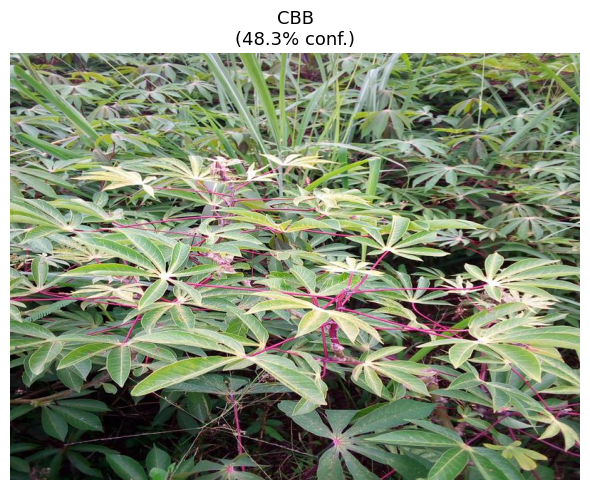

In [ ]:

import matplotlib.pyplot as plt
from PIL import Image
import os
import torch
import numpy as np

TEST_DIR = 'cassava_data/test_images'
test_files = os.listdir(TEST_DIR)
print(f"Test images count: {len(test_files)}")

cassava_classes = ['CBB', 'CBSD', 'CGM', 'CMD', 'Healthy']

dino_model.eval()

img_name = test_files[0]
img_path = os.path.join(TEST_DIR, img_name)
img = Image.open(img_path).convert("RGB")
img_tensor = dinov2_val_transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    output = dino_model(img_tensor)
    probs = torch.softmax(output, dim=1)
    pred_idx = torch.argmax(probs, dim=1).item()
    confidence = probs[0, pred_idx].item()

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"{cassava_classes[pred_idx]}\n({confidence*100:.1f}% conf.)", fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Cassava_Project/plots/test_predictions_visual.png', dpi=200, bbox_inches='tight')
plt.show()